## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, timedelta

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [3]:
from funcoes_monitoramento import *
from funcoes_psi import *

## Diretório

In [4]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Base Blend4 em Produção

In [5]:
df_raw = pd.read_csv(ANALYTICS_DIR/"df_predict_blend4.csv")

In [6]:
df_uniprop = df_raw[df_raw["qtd_proponentes"] == 1].copy()

df_multprop = df_raw[df_raw["qtd_proponentes"] >= 2].copy()

In [7]:
df = df_uniprop[(df_uniprop["REGRA_BLEND_4"] == "BLEND4")
&(df_uniprop["income"] > 0) #Essa regra deverá ser excluída quando o modelo for implementado
].copy()

In [8]:
df_bvs = df_uniprop[(df_uniprop["REGRA_BLEND_4"] == "E_BVS")
].copy()

In [9]:
df_uniprop = prepare_week_columns(df_uniprop, "requested_at")
df_multprop = prepare_week_columns(df_multprop, "requested_at")
df = prepare_week_columns(df, "requested_at")
df_bvs = prepare_week_columns(df_bvs, "requested_at")

In [10]:

# df = df_raw[df_raw["message_decisao"].isin(["BLEND_4", "BLEND3_3"])]
# df_bvs = df_raw[df_raw["message_decisao"].isin(["BLEND_4", "BLEND3_3"])]

## Gráficos

In [11]:
MODEL_ORDER = [
    "BLEND4",
    "BLEND3_3",
    "BLEND_REGRESSAO_2026",
    "BVS_CUSTOM",
    "HVA3",
    "HVA4",
]

MODEL_ORDER_GRAPH = [
    "BLEND4",
    "BLEND3_3",
]

MODEL_COLOR_MAP = {
    "BLEND4": "#3B82F6",             # blue
    "BLEND3_3": "#94A3B8",           # slate
    "BLEND_REGRESSAO_2026": "#8B5CF6",  # violet
    "BVS_CUSTOM": "#06B6D4",        # cyan
    "HVA3": "#14B8A6",               # teal
    "HVA4": "#6366F1",               # indigo
}

RATING_ORDER = ["A", "B", "C", "D", "E"]

RATING_COLOR_MAP = {
    "A": "#7DD3FC",
    "B": "#5EEAD4",
    "C": "#93C5FD",
    "D": "#818CF8",
    "E": "#334155",
}
RATING_TEXT_COLOR_MAP = {
    "A": "white",
    "B": "white",
    "C": "black",
    "D": "white",
    "E": "white",
}

In [12]:
PRE_ANALISE_ORDER = ["APROVAR", "DERIVAR", "REPROVAR"]

PRE_ANALISE_COLOR_MAP = {
    "APROVAR": "#9ECACA",
    "DERIVAR": "#B5BFE8",
    "REPROVAR": "#9AA5B1",
}

PRE_ANALISE_TEXT_COLOR_MAP = {
    "APROVAR": "white",
    "DERIVAR": "white",
    "REPROVAR": "white",
}

In [13]:
BINARY_METRICS = [
    "lead_elegivel_pre_analysis",
    "sent",
    "activated",
]

BINARY_ORDER = [0, 1]

BINARY_COLOR_MAP = {
    0: "#CBD5E1",  # muted gray
    1: "#86B8B8",  # muted teal (same family as APROVAR)
}

BINARY_TEXT_COLOR_MAP = {
    0: "white",
    1: "white",
}

BINARY_LABELS = {
    "lead_elegivel_pre_analysis": {0: "Não elegível", 1: "Elegível"},
    "sent": {0: "Não enviado", 1: "Enviado"},
    "activated": {0: "Não ativado", 1: "Ativado"},
}

METRIC_TITLES = {
    "lead_elegivel_pre_analysis": "Elegível",
    "sent": "Enviado",
    "activated": "Ativado",
}

## Multiproponente vs. Uniproponente

In [14]:
PROPONENTE_ORDER = ["Uniproponente", "Multiproponente"]

PROPONENTE_COLOR_MAP = {
    "Uniproponente": "#94A3B8",   # slate
    "Multiproponente": "#3B82F6", # blue
}

PROPONENTE_TEXT_COLOR_MAP = {
    "Uniproponente": "white",
    "Multiproponente": "white",
}

def add_tipo_proponente(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["tipo_proponente"] = np.where(
        out["qtd_proponentes"] == 1,
        "Uniproponente",
        "Multiproponente",
    )
    return out

# Use df (BLEND4 + income > 0) ou df_raw (base completa)
df_prop = add_tipo_proponente(df_raw)

print(df_prop["tipo_proponente"].value_counts(normalize=True).mul(100).round(2))
print(df_prop["tipo_proponente"].value_counts())

tipo_proponente
Uniproponente      97.93
Multiproponente     2.07
Name: proportion, dtype: float64
tipo_proponente
Uniproponente      197658
Multiproponente      4180
Name: count, dtype: int64


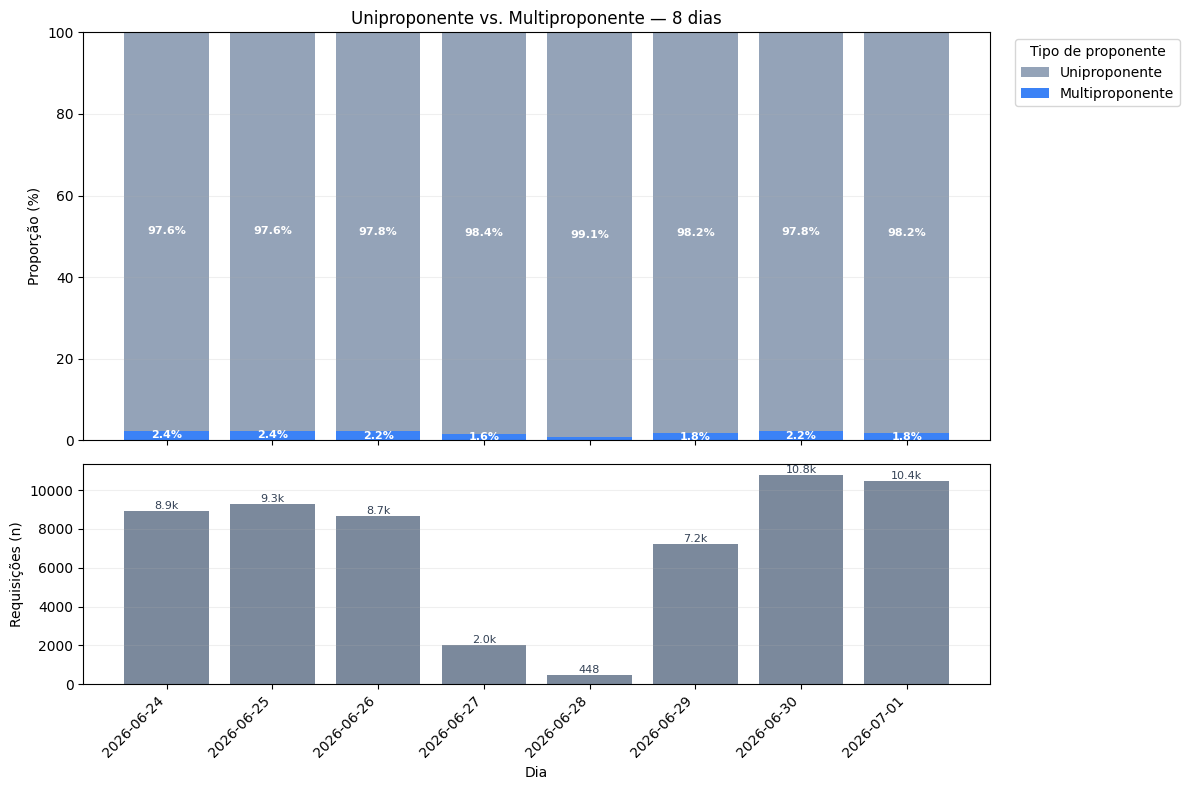

In [15]:
WINDOW_DAYS = 8

df_daily_prop = filter_monitoring_window(
    df_prop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)

plot_daily_mix(
    df_daily_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_DAYS} dias",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

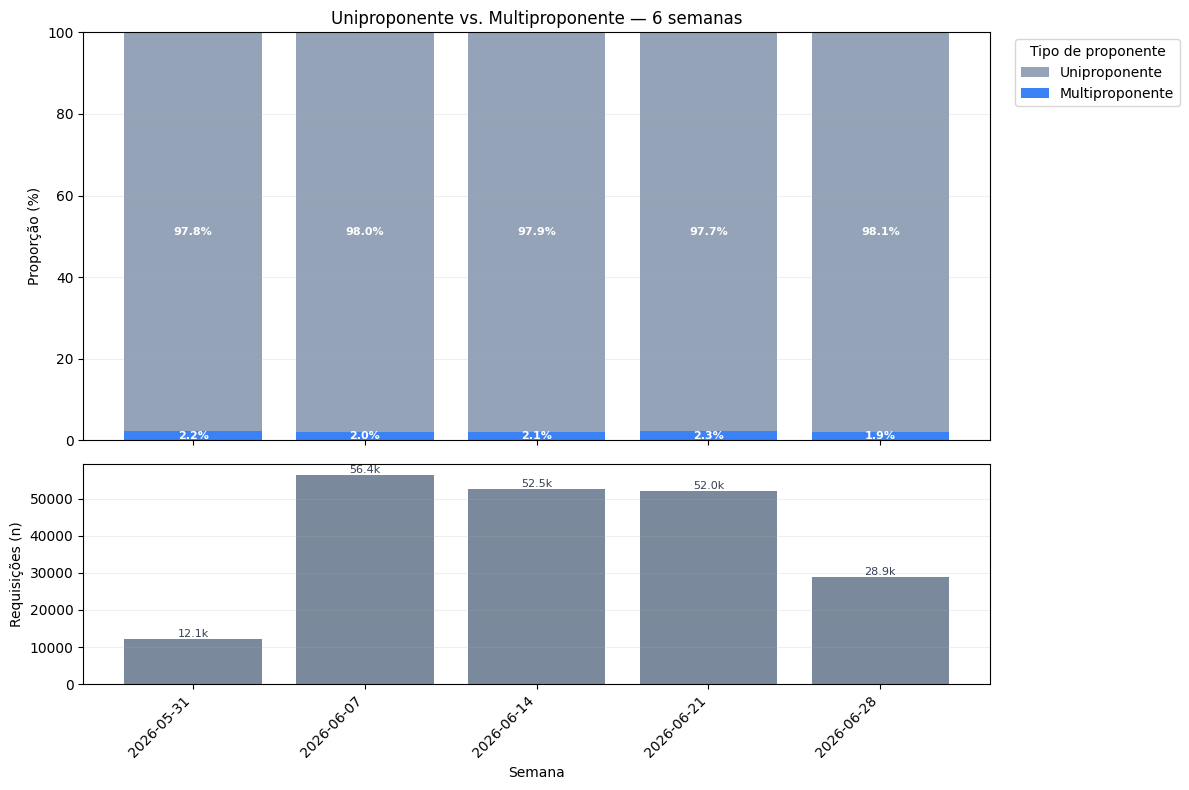

In [16]:
WINDOW_WEEKS = 6

df_weekly_prop = filter_monitoring_week_window(
    df_prop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)

plot_weekly_mix(
    df_weekly_prop,
    category_col="tipo_proponente",
    title=f"Uniproponente vs. Multiproponente — {WINDOW_WEEKS} semanas",
    category_order=PROPONENTE_ORDER,
    color_map=PROPONENTE_COLOR_MAP,
    text_color_map=PROPONENTE_TEXT_COLOR_MAP,
    reverse_stack=True,
    legend_title="Tipo de proponente",
    min_label_pct=1.0,
)

# Uniproponente

# Primeira Semana
Na primeira semana, é interessante acompanhar os dados ao longo dos dias. Temos disponíveis os dados em D-1.

In [17]:
WINDOW_DAYS = 8

df_daily = filter_monitoring_window(
    df,
    n_days=WINDOW_DAYS,
    mode="rolling",
)
print(f"Período: {df_daily['requested_at'].min()} → {df_daily['requested_at'].max()}")
print(f"Volume total: {len(df_daily):,}")

Período: 2026-06-24 00:00:00 → 2026-07-01 00:00:00
Volume total: 46,482


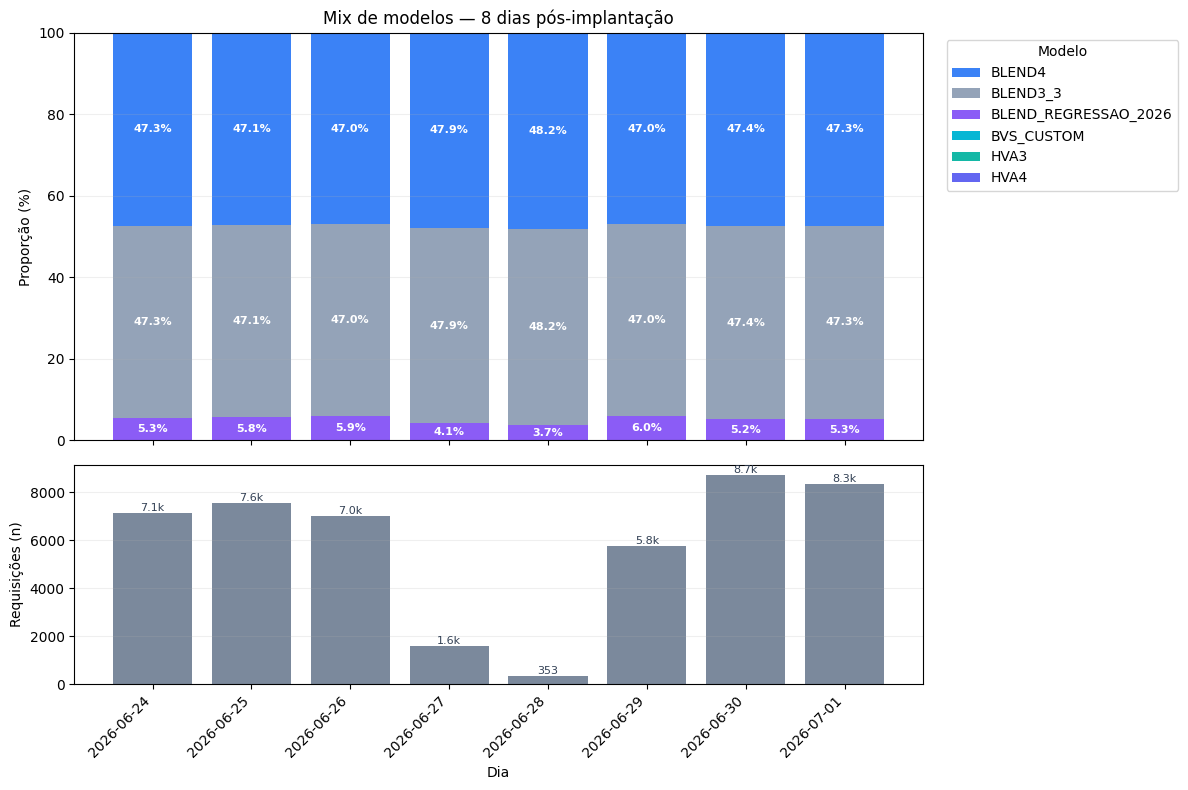

In [18]:
plot_daily_mix(
    df_daily,
    category_col="message_decisao",
    title=f"Mix de modelos — {WINDOW_DAYS} dias pós-implantação",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=3.0,
)

## Rating Json

In [19]:
# # Geral
# plot_daily_mix(
#     df_daily,
#     category_col="message_classificacao",
#     title=f"Mix de rating geral — {WINDOW_DAYS} dias pós-implantação",
#     category_order=RATING_ORDER,
#     color_map=RATING_COLOR_MAP,
#     text_color_map=RATING_TEXT_COLOR_MAP,
#     reverse_stack=True,
#     legend_title="Rating",
#     min_label_pct=3.0,
#     show_volume=False,
# )

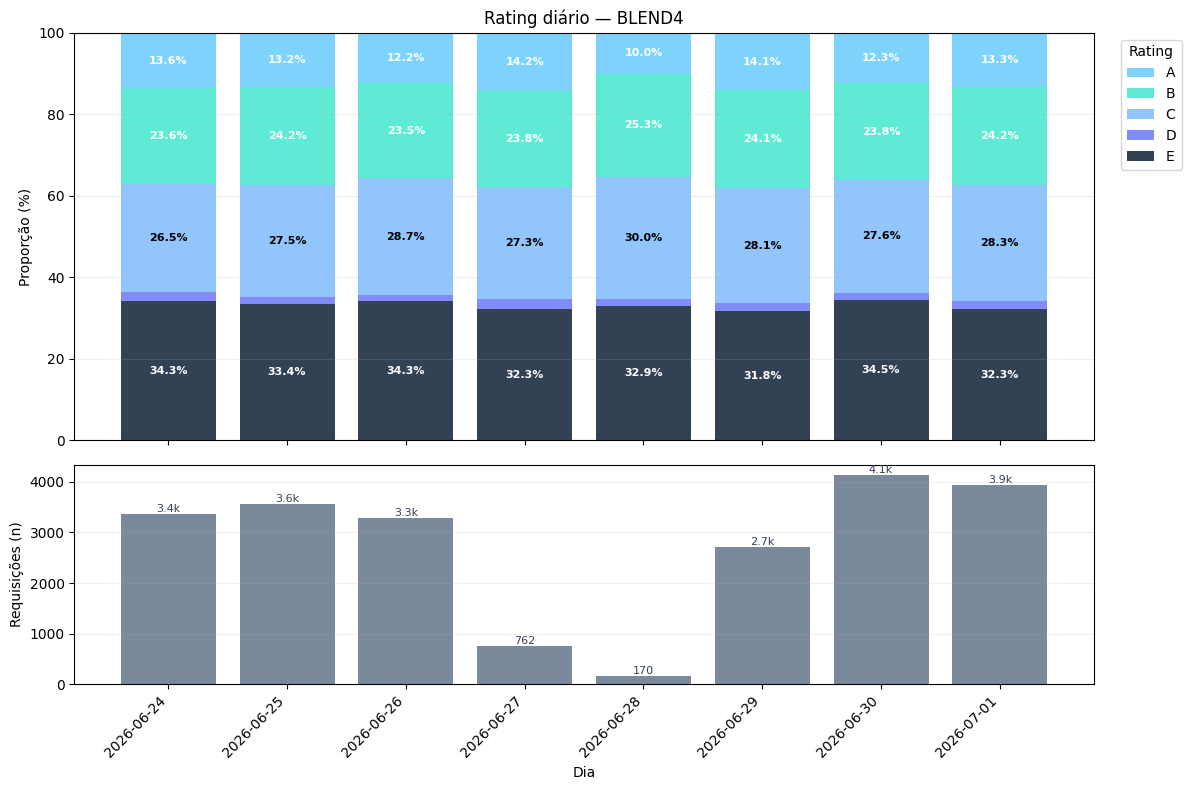

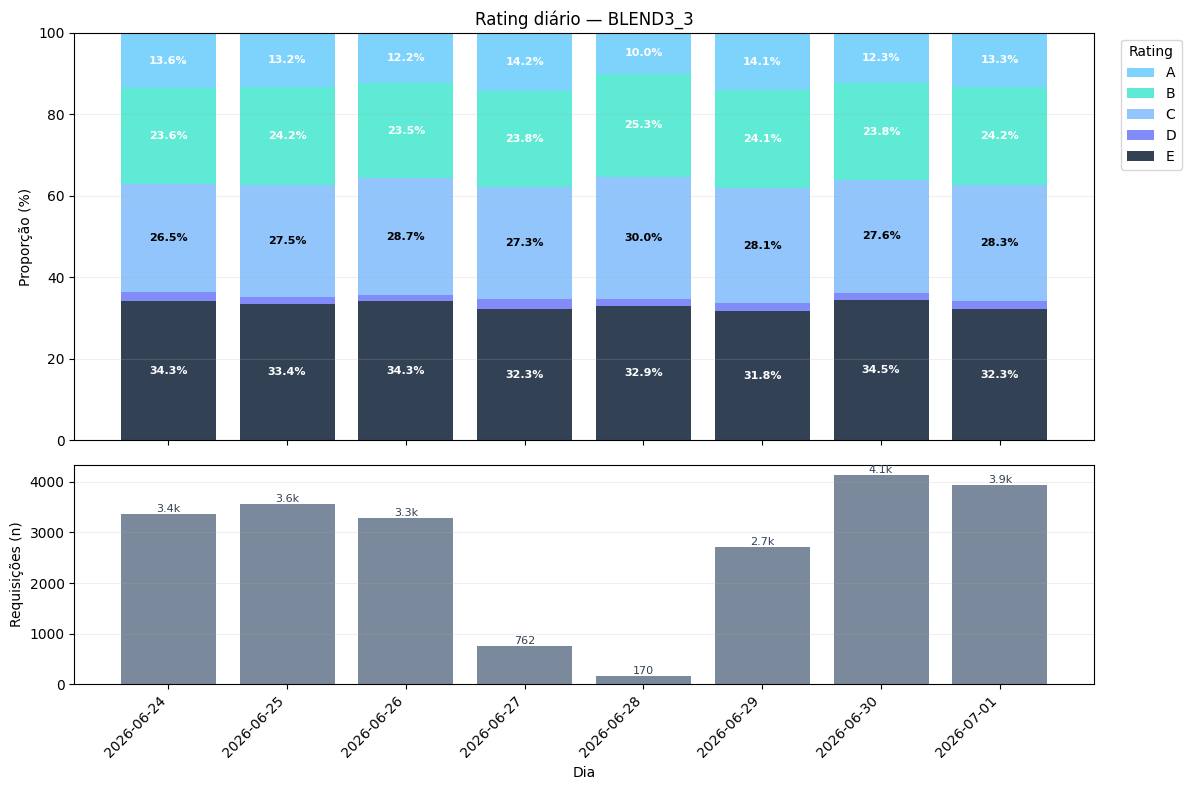

In [20]:
# Por modelo
for model in MODEL_ORDER_GRAPH:
    df_model = df_daily[df_daily["message_decisao"] == model]
    if df_model.empty:
        continue

    plot_daily_mix(
        df_model,
        category_col="message_classificacao",
        title=f"Rating diário — {model}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        legend_title="Rating",
        min_label_pct=5.0,
    )

# Avaliação Semanal

In [21]:
WINDOW_WEEKS = 6

df_weekly = filter_monitoring_week_window(
    df,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)
print(f"Semanas: {df_weekly['year_week'].nunique()} | Volume: {len(df_weekly):,}")
print(f"Período: {df_weekly['requested_at'].min()} → {df_weekly['requested_at'].max()}")

Semanas: 5 | Volume: 162,957
Período: 2026-06-04 00:00:00 → 2026-07-01 00:00:00


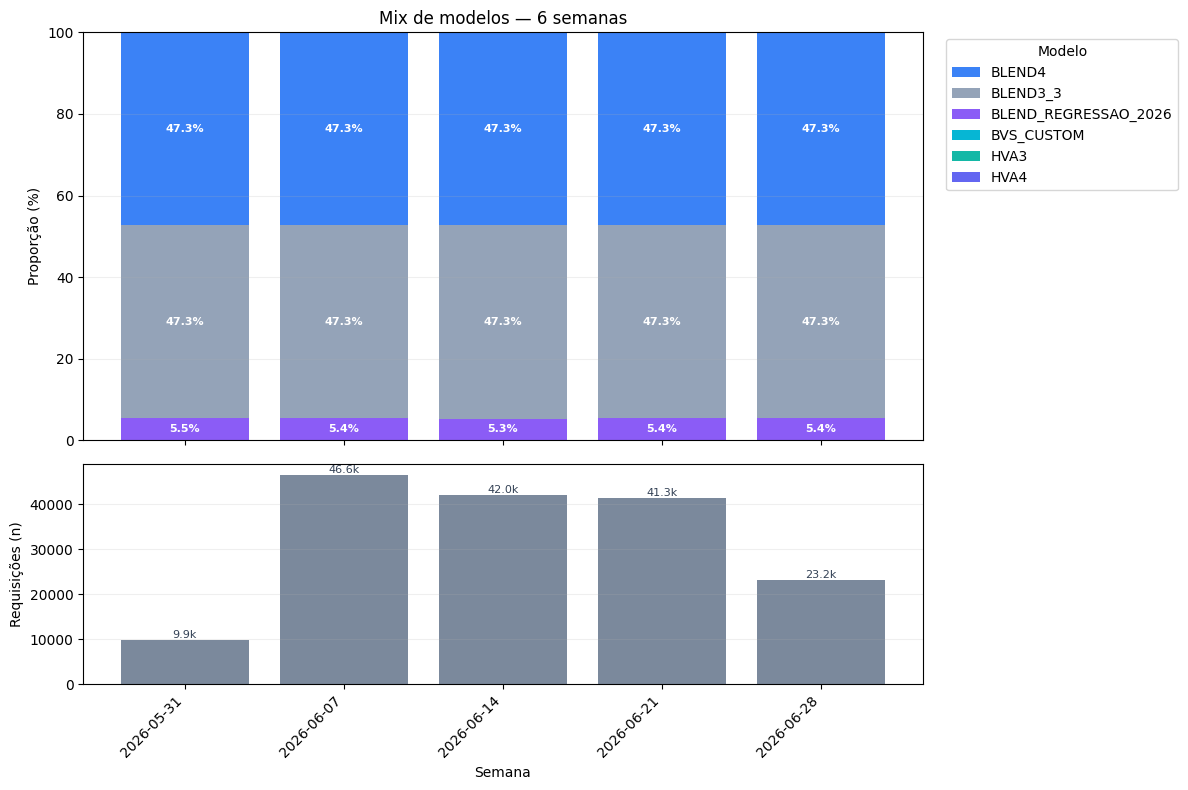

In [22]:
# Geral — modelos
plot_weekly_mix(
    df_weekly,
    category_col="message_decisao",
    title=f"Mix de modelos — {WINDOW_WEEKS} semanas",
    category_order=MODEL_ORDER,
    color_map=MODEL_COLOR_MAP,
    reverse_stack=True,
    legend_title="Modelo",
    min_label_pct=3.0,
)

## Mix de Rating por Modelo

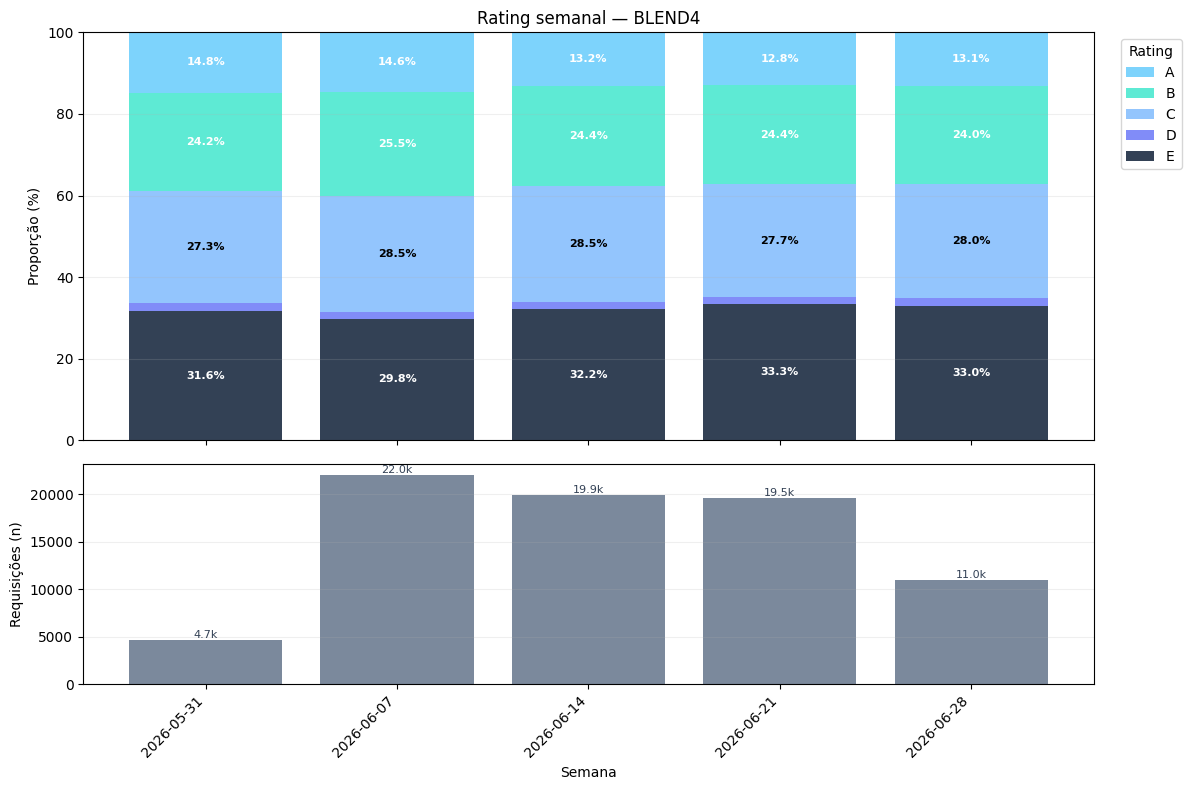

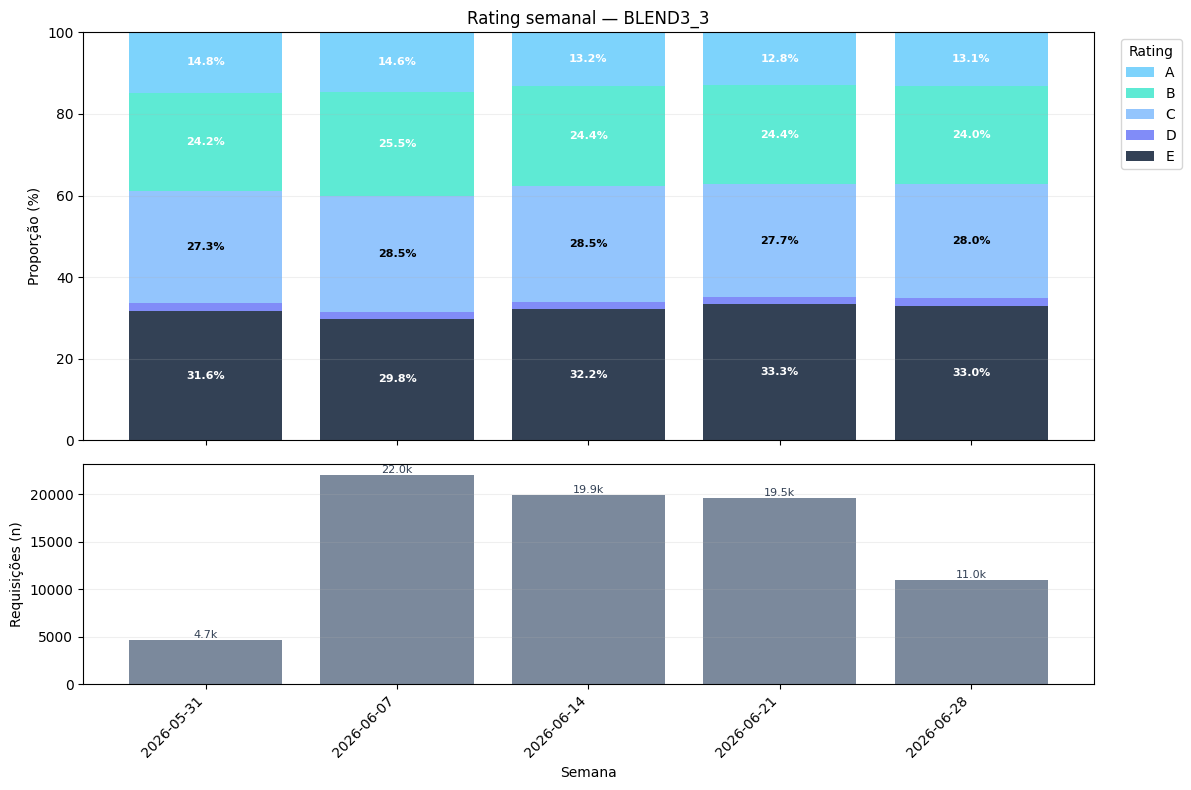

In [25]:
for model in MODEL_ORDER_GRAPH:
    df_model = df_weekly[df_weekly["message_decisao"] == model]
    if df_model.empty:
        continue

    plot_weekly_mix(
        df_model,
        category_col="message_classificacao",
        title=f"Rating semanal — {model}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        legend_title="Rating",
        min_label_pct=5.0,
    )

# Escoragem Manual

## Score

In [26]:
df_blend4 = df[df['message_decisao'].isin(['BLEND4'])]

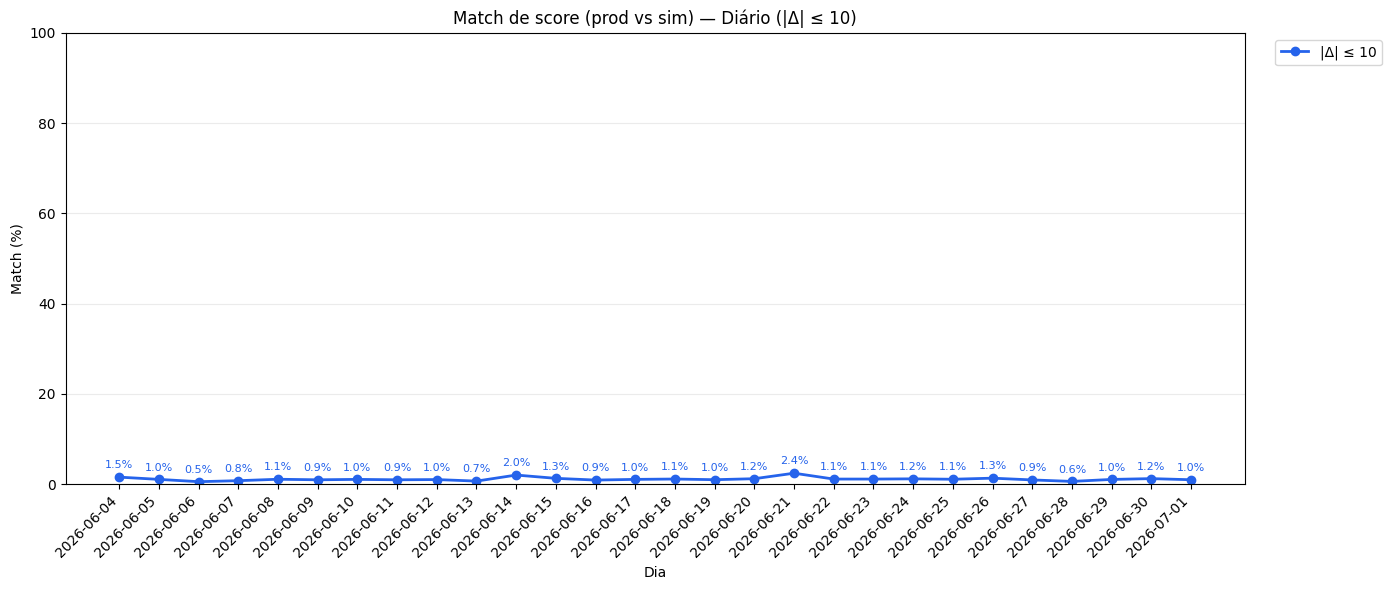

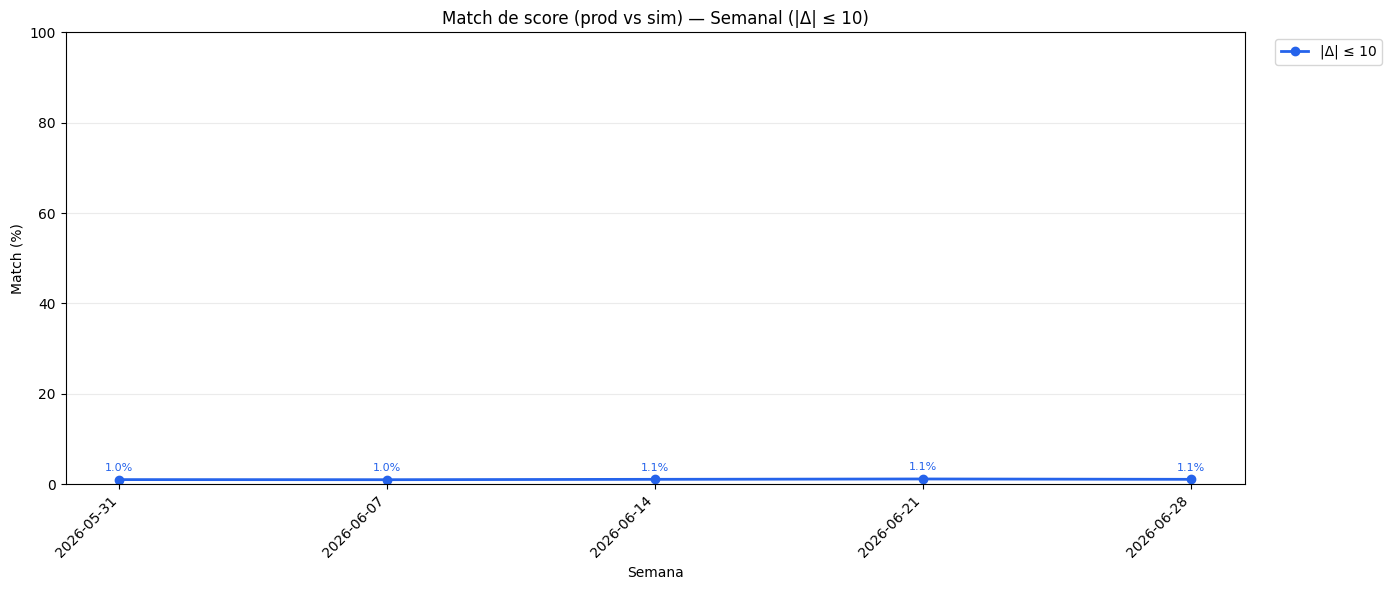

In [27]:
# Tabelas (como o score_summary que você já usa, mas por período)
daily_summary, weekly_summary = plot_score_match_monitoring(
    df_blend4,
    production_score_col="message_blendRegressaoPredict",
    simulated_score_col="pred_blend4_1_to_score",
    model_col=None,          # geral; use "message_decisao" para linha por modelo
    match_tolerance=10,      # coluna pct_match_abs_le_10
    show_volume=False,
)

In [28]:
daily_summary[["period", "volume_total", "pct_match_abs_le_10", "score_abs_diff_mean"]]

,period,volume_total,pct_match_abs_le_10,score_abs_diff_mean
0,2026-06-04,455.0,1.54,143.2
1,2026-06-05,3454.0,1.04,137.9
2,2026-06-06,755.0,0.53,140.4
3,2026-06-07,134.0,0.75,144.1
4,2026-06-08,5043.0,1.07,140.3
5,2026-06-09,5911.0,0.95,136.3
6,2026-06-10,3953.0,1.04,140.1
7,2026-06-11,3570.0,0.95,142.3
8,2026-06-12,2793.0,1.00,145.3
9,2026-06-13,603.0,0.66,146.6


## Rating

## Comparação Rating Escoragem Manual

In [29]:
MODELS = ["BLEND_4"]

for model in MODELS:
    df_model = df_daily[df_daily["message_decisao"] == model]

    plot_daily_rating_comparison(
        df_model,
        title=f"Rating diário — {model} (Produção vs Simulado Manual)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_manual_blend4",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

[skip] Sem dados para: Rating diário — BLEND_4 (Produção vs Simulado Manual)


In [30]:
for model in MODELS:
    pivot = pd.crosstab(
        df_daily.loc[df_daily["message_decisao"] == model, "message_classificacao"],
        df_daily.loc[df_daily["message_decisao"] == model, "rating_manual_blend4"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND_4


rating_manual_blend4
message_classificacao


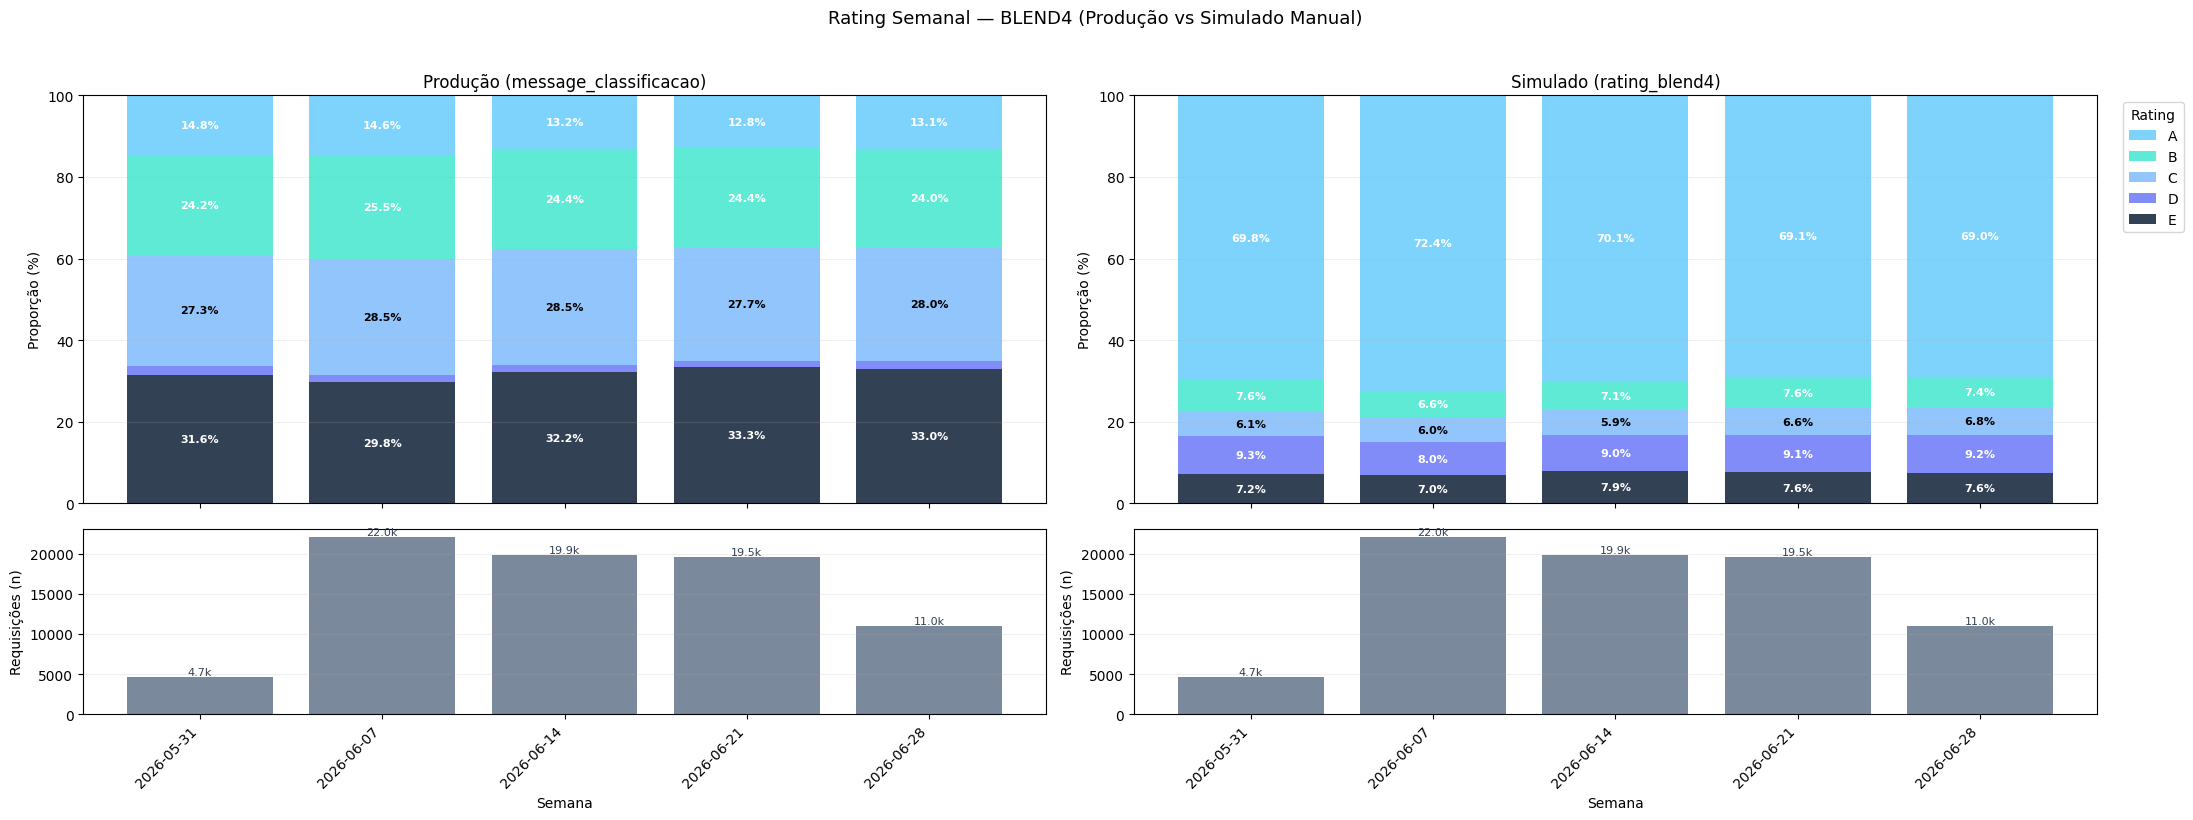

In [31]:
MODELS = ["BLEND4"]

for model in MODELS:
    df_model = df_weekly[df_weekly["message_decisao"] == model]

    plot_weekly_rating_comparison(
        df_model,
        title=f"Rating Semanal — {model} (Produção vs Simulado Manual)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_manual_blend4",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

In [32]:
for model in MODELS:
    pivot = pd.crosstab(
        df_weekly.loc[df_weekly["message_decisao"] == model, "message_classificacao"],
        df_weekly.loc[df_weekly["message_decisao"] == model, "rating_manual_blend4"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND4


rating_manual_blend4,A,B,C,D,E,All
message_classificacao,,,,,,
A,10456,10,3,0,2,10471
B,18761,141,44,33,15,18994
C,19271,1406,610,314,98,21699
D,797,299,175,55,0,1326
E,4894,3684,3970,6378,5638,24564
All,54179,5540,4802,6780,5753,77054


## Comparação Rating Json
A questão aqui é se o message_classificacao está vindo correto, ou seja, se os cortes estão sendo feitos corretamente.

In [33]:
MODELS = ["BLEND_4"]

for model in MODELS:
    df_model = df_daily[df_daily["message_decisao"] == model]

    plot_daily_rating_comparison(
        df_model,
        title=f"Rating diário — {model} (Produção vs Simulado Json)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_json_blend4",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

[skip] Sem dados para: Rating diário — BLEND_4 (Produção vs Simulado Json)


In [34]:
for model in MODELS:
    pivot = pd.crosstab(
        df_daily.loc[df_daily["message_decisao"] == model, "message_classificacao"],
        df_daily.loc[df_daily["message_decisao"] == model, "rating_json_blend4"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND_4


rating_json_blend4
message_classificacao


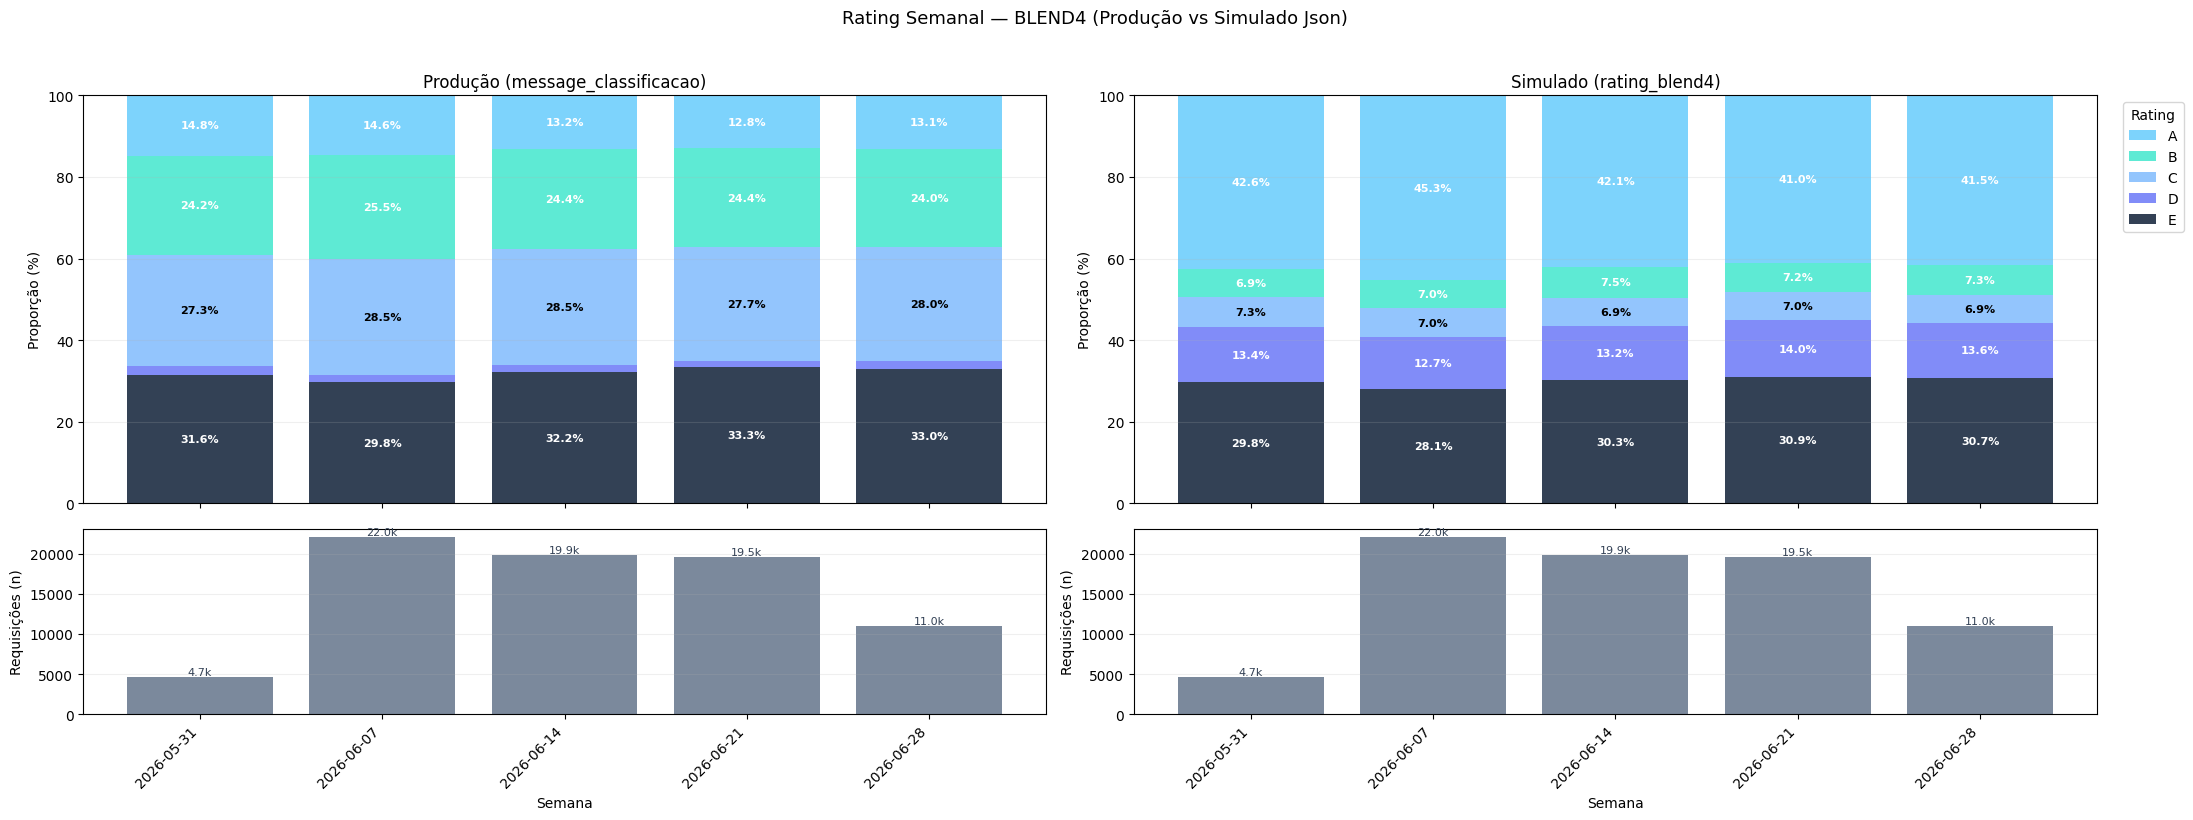

In [35]:
MODELS = ["BLEND4"]

for model in MODELS:
    df_model = df_weekly[df_weekly["message_decisao"] == model]

    plot_weekly_rating_comparison(
        df_model,
        title=f"Rating Semanal — {model} (Produção vs Simulado Json)",
        production_rating_col = "message_classificacao",
        simulated_rating_col = "rating_json_blend4",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
    )

In [36]:
for model in MODELS:
    pivot = pd.crosstab(
        df_weekly.loc[df_weekly["message_decisao"] == model, "message_classificacao"],
        df_weekly.loc[df_weekly["message_decisao"] == model, "rating_json_blend4"],
        margins=True,
    )
    print(model)
    display(pivot)

BLEND4


rating_json_blend4,A,B,C,D,E,All
message_classificacao,,,,,,
A,9919,224,130,104,94,10471
B,15629,1186,631,787,761,18994
C,7322,4134,4618,3001,2624,21699
D,0,0,0,1326,0,1326
E,1,2,1,5034,19526,24564
All,32871,5546,5380,10252,23005,77054


## PSI

In [37]:
model_vars = [
    "score_proposto__bvs__normalized4_1",
    "SERASA_CHSV5__normalized4_1",
    "age__normalized4_1",
    "property_type",
    "qtde_restricoes__consulta_realizada__normalized4_1",
    "income_commitment__normalized4_1",
    "agency_pc4_mais_100_contratos__pc_categorias__normalized4_1",
    "city_pc4_mais_100_contratos__pc_categorias__normalized4_1",
    "flag_tem__contratos_anteriores",
    "flag_teve_boleto_atrasado__contratos_anteriores",
    "agency_pc4_mais_100_contratos__pc_categorias_is_null",
    "city_pc4_mais_100_contratos__pc_categorias_is_null",
    "pred_blend4_1_to_score"
]

In [38]:
VARIABLE_LABELS = {
    "score_proposto__bvs__normalized4_1": "Score BVS",
    "SERASA_CHSV5__normalized4_1": "Score Serasa CHSV5",
    "age__normalized4_1": "Idade",
    "property_type": "Tipo de imóvel",
    "qtde_restricoes__consulta_realizada__normalized4_1": "Qtd. restrições",
    "income_commitment__normalized4_1": "Comprometimento de renda",
    "agency_pc4_mais_100_contratos__pc_categorias__normalized4_1": "PC categorias — agência (100+ contratos)",
    "city_pc4_mais_100_contratos__pc_categorias__normalized4_1": "PC categorias — cidade (100+ contratos)",
    "flag_tem__contratos_anteriores": "Tem contratos anteriores",
    "flag_teve_boleto_atrasado__contratos_anteriores": "Boleto atrasado (contratos anteriores)",
    "agency_pc4_mais_100_contratos__pc_categorias_is_null": "PC categorias agência — nulo",
    "city_pc4_mais_100_contratos__pc_categorias_is_null": "PC categorias cidade — nulo",
    "pred_blend4_1_to_score": "Score Blend Regressão"
}

In [39]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend4_psi_reference.pkl"
PSI_BASELINE_PATH = ANALYTICS_DIR / "blend4_psi_baseline_ref.csv"

psi_reference_artifact = load_psi_reference(PSI_REFERENCE_PATH)
psi_baseline_ref = pd.read_csv(PSI_BASELINE_PATH)

In [40]:
daily_blend4 = df_daily[df_daily["message_decisao"] == "BLEND4"].copy()
weekly_blend4 = df_weekly[df_weekly["message_decisao"] == "BLEND4"].copy()

psi_daily = monitor_daily_psi(
    df_production=daily_blend4,
    artifact=psi_reference_artifact,
    date_col="requested_at",
    baseline_ref=psi_baseline_ref,
    variables=model_vars,
)

psi_weekly = monitor_weekly_psi(
    df_production=weekly_blend4,
    artifact=psi_reference_artifact,
    baseline_ref=psi_baseline_ref,
    variables=model_vars,
)

In [41]:
# target_day = (date.today() - timedelta(days=1)).strftime("%Y-%m-%d")
target_day = pd.to_datetime(daily_blend4["requested_at"]).max().strftime("%Y-%m-%d")
print(f"Target day: {target_day}")
df_day = daily_blend4[
    pd.to_datetime(daily_blend4["requested_at"]).dt.strftime("%Y-%m-%d") == target_day
]

psi_day = calculate_psi_table_from_reference(
    df_actual=df_day,
    artifact=psi_reference_artifact,
    comparison_label="production_vs_train",
    variables=model_vars,
)

psi_day.merge(psi_baseline_ref, on="variable", how="left")

Target day: 2026-07-01


,variable,comparison,psi,status,n_actual,psi_oot_vs_train_ref,psi_test_vs_train_ref
0,score_proposto__bvs__normalized4_1,production_vs_train,1.544922,unstable,3944,0.010233,0.000116
1,pred_blend4_1_to_score,production_vs_train,0.347781,unstable,3944,0.023761,0.000040
2,SERASA_CHSV5__normalized4_1,production_vs_train,0.199756,moderate,3944,0.020552,0.000130
3,city_pc4_mais_100_contratos__pc_categorias__no...,production_vs_train,0.055839,stable,3944,0.054831,0.000085
4,income_commitment__normalized4_1,production_vs_train,0.027493,stable,3944,0.000870,0.000048
5,qtde_restricoes__consulta_realizada__normalize...,production_vs_train,0.012542,stable,3944,0.023595,0.000028
6,age__normalized4_1,production_vs_train,0.003404,stable,3944,0.001148,0.000071
7,city_pc4_mais_100_contratos__pc_categorias_is_...,production_vs_train,0.003082,stable,3944,0.000236,0.000011
8,flag_teve_boleto_atrasado__contratos_anteriores,production_vs_train,0.002560,stable,3944,0.000237,0.000002
9,flag_tem__contratos_anteriores,production_vs_train,0.001020,stable,3944,0.000000,0.000002


In [42]:
week_order = (
    weekly_blend4[["year_week", "week_start"]]
    .drop_duplicates()
    .sort_values("week_start")["year_week"]
    .tolist()
)
week_order

['2026-05-31', '2026-06-07', '2026-06-14', '2026-06-21', '2026-06-28']

In [43]:
# target_week = weekly_blend4.year_week.max()
# print(f"Target Week == {target_week} (Semana Corrente)")
# df_week = weekly_blend4[
#     weekly_blend4["year_week"] == target_week]

# psi_week = calculate_psi_table_from_reference(
#     df_actual=df_week,
#     artifact=psi_reference_artifact,
#     comparison_label="production_vs_train",
#     variables=model_vars,
# )

# psi_week.merge(psi_baseline_ref, on="variable", how="left")

In [44]:
target_week = target_week = week_order[-2]
print(f"Target Week == {target_week} (Semana Anterior Completa)")
df_week = weekly_blend4[
    weekly_blend4["year_week"] == target_week]

psi_week = calculate_psi_table_from_reference(
    df_actual=df_week,
    artifact=psi_reference_artifact,
    comparison_label="production_vs_train",
    variables=model_vars,
)

psi_week.merge(psi_baseline_ref, on="variable", how="left")

Target Week == 2026-06-21 (Semana Anterior Completa)


,variable,comparison,psi,status,n_actual,psi_oot_vs_train_ref,psi_test_vs_train_ref
0,score_proposto__bvs__normalized4_1,production_vs_train,1.521260,unstable,19537,0.010233,0.000116
1,pred_blend4_1_to_score,production_vs_train,0.350654,unstable,19537,0.023761,0.000040
2,SERASA_CHSV5__normalized4_1,production_vs_train,0.208414,moderate,19537,0.020552,0.000130
3,city_pc4_mais_100_contratos__pc_categorias__no...,production_vs_train,0.070288,stable,19537,0.054831,0.000085
4,income_commitment__normalized4_1,production_vs_train,0.026789,stable,19537,0.000870,0.000048
5,qtde_restricoes__consulta_realizada__normalize...,production_vs_train,0.019693,stable,19537,0.023595,0.000028
6,city_pc4_mais_100_contratos__pc_categorias_is_...,production_vs_train,0.004793,stable,19537,0.000236,0.000011
7,age__normalized4_1,production_vs_train,0.001349,stable,19537,0.001148,0.000071
8,flag_teve_boleto_atrasado__contratos_anteriores,production_vs_train,0.000971,stable,19537,0.000237,0.000002
9,flag_tem__contratos_anteriores,production_vs_train,0.000797,stable,19537,0.000000,0.000002


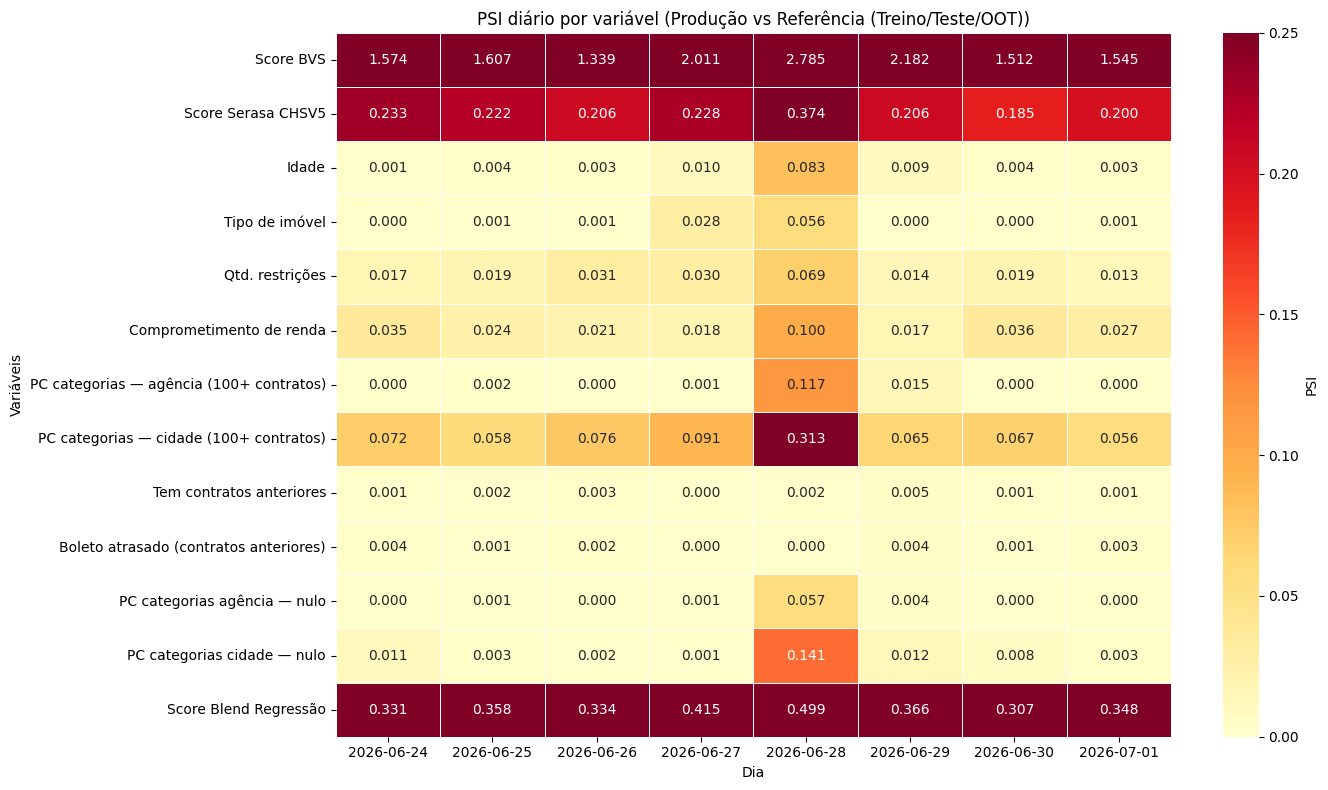

In [45]:
pivot = (
    psi_daily
    .pivot(index="variable", columns="monitoring_day", values="psi")
    .reindex(model_vars)
    .rename(index=VARIABLE_LABELS)
)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI diário por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Dia")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

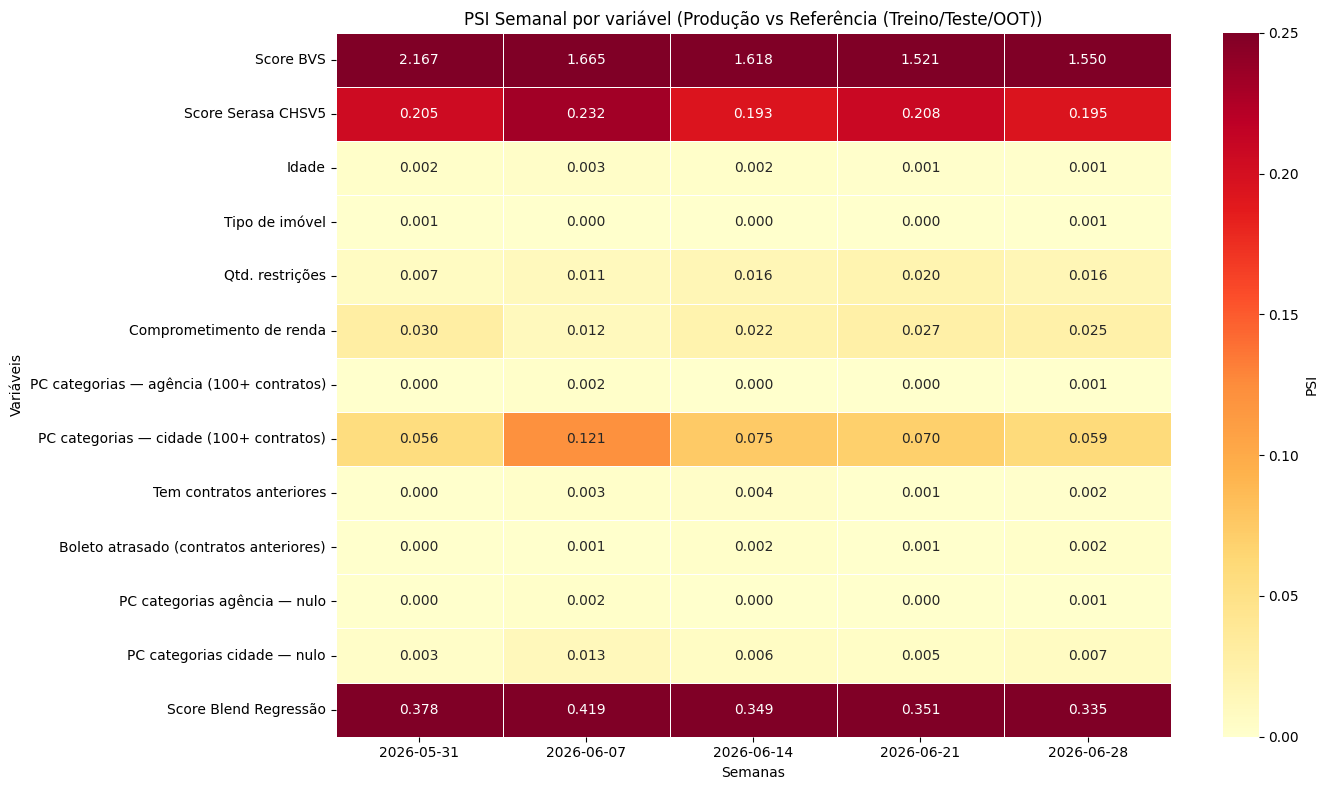

In [46]:
pivot = (
    psi_weekly
    .pivot(index="variable", columns="monitoring_week", values="psi")
    .reindex(index=model_vars, columns=week_order)
    .rename(index=VARIABLE_LABELS)
)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI Semanal por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Semanas")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

Trazer: Verificar se houve aumento real de aluguel

Tirar o 0 da Renda Serasa?
Acompanhar Renda e Score

Matriz por dia: Acompanhar preenchimento/valor especial. Percentual de Falha. Acompanhar Volume.

Acompanhar variável Renda (Serasa) e Aluguel
Investigar Comprometimento de Renda
Investigar variável PC cat cidades (Tabela Criação da PC das Cidades)

## PSI D-1

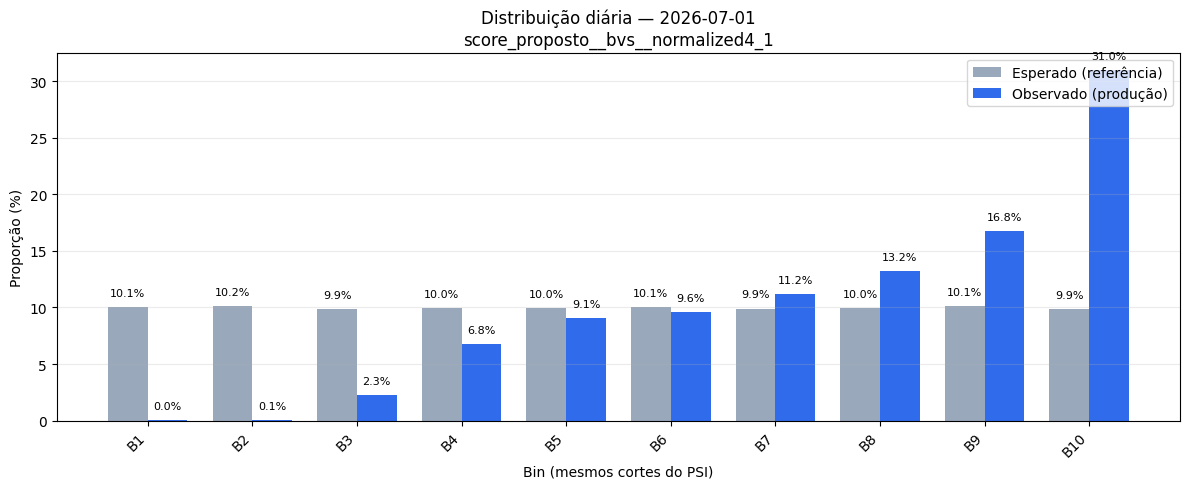

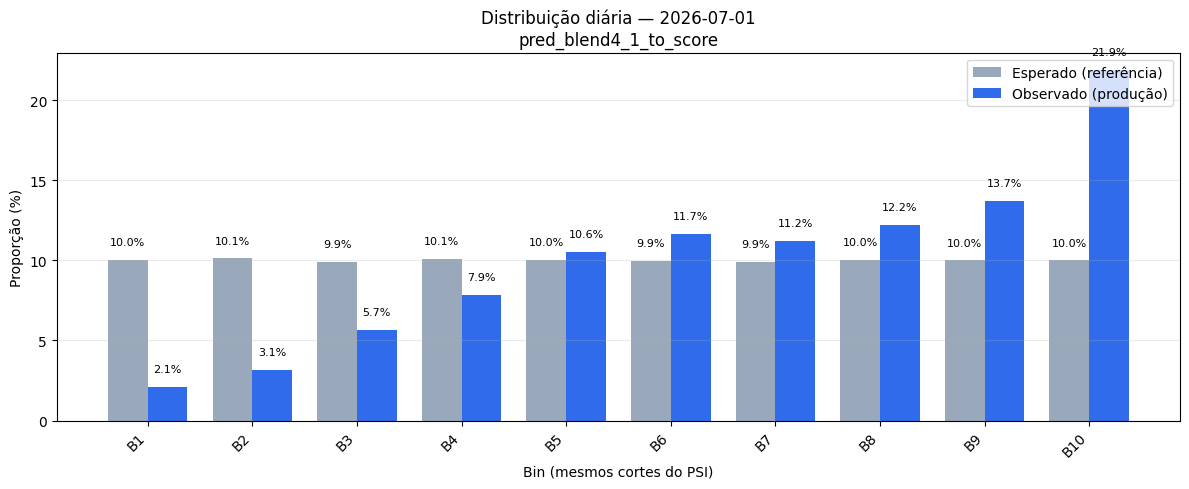

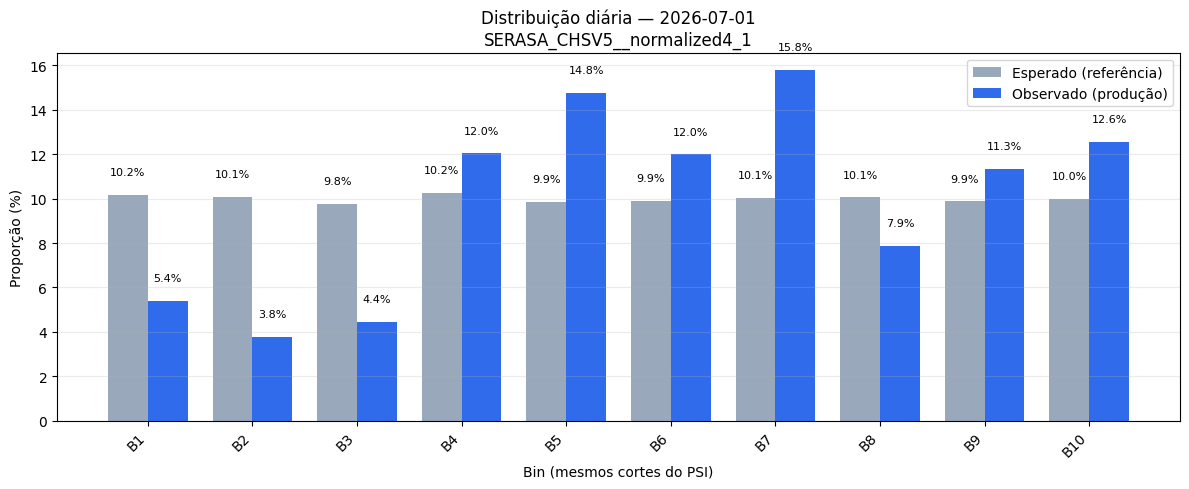

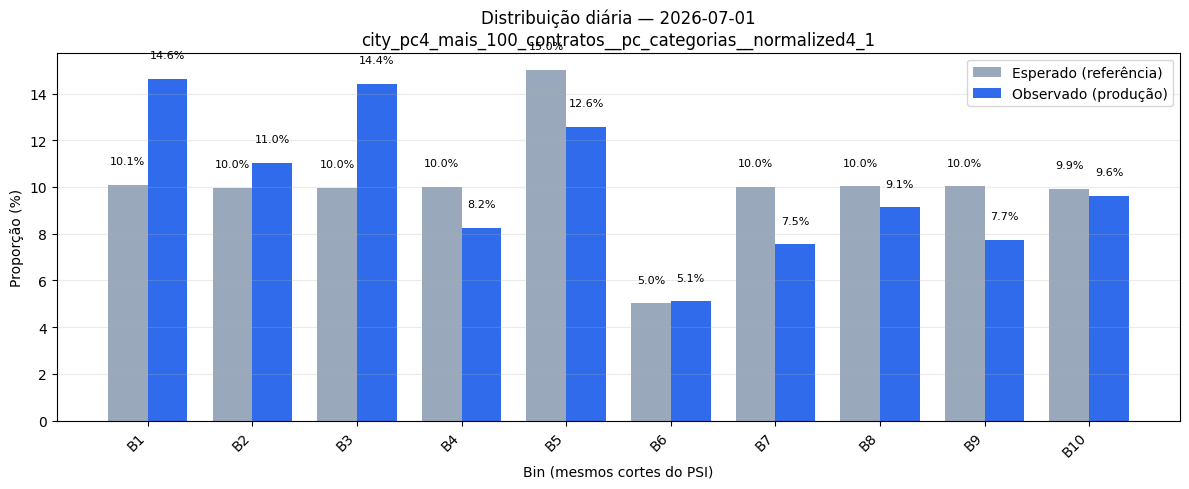

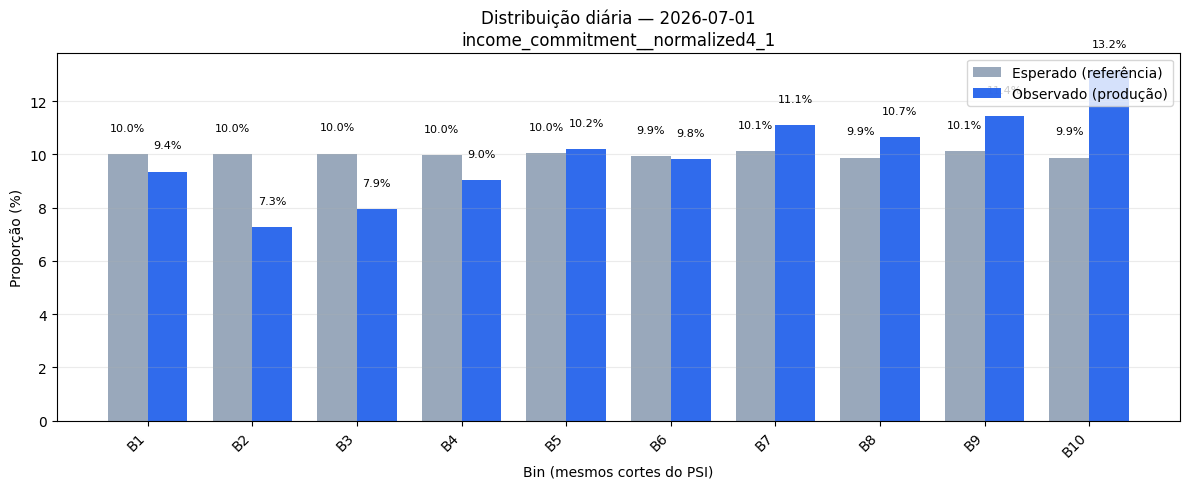

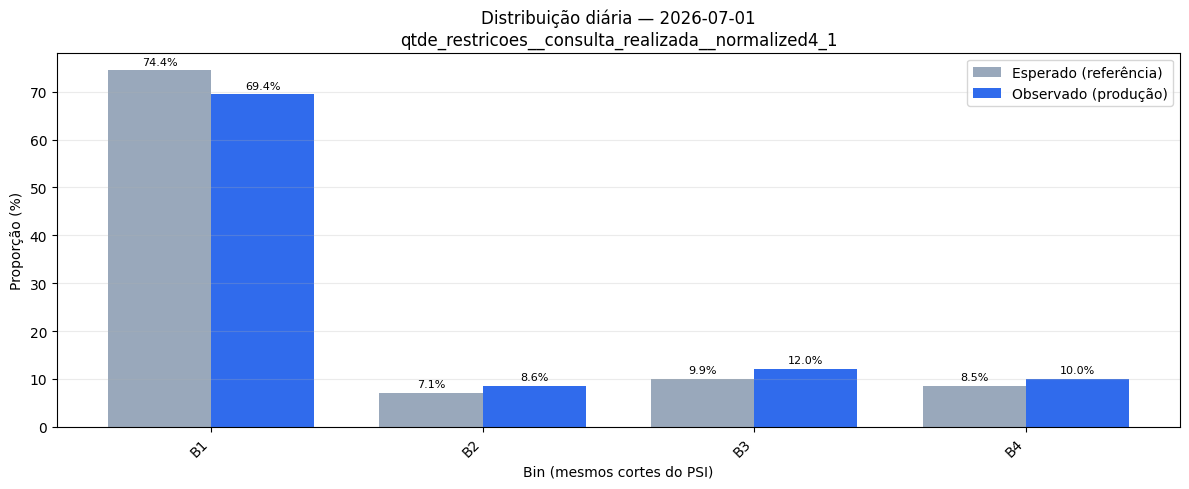

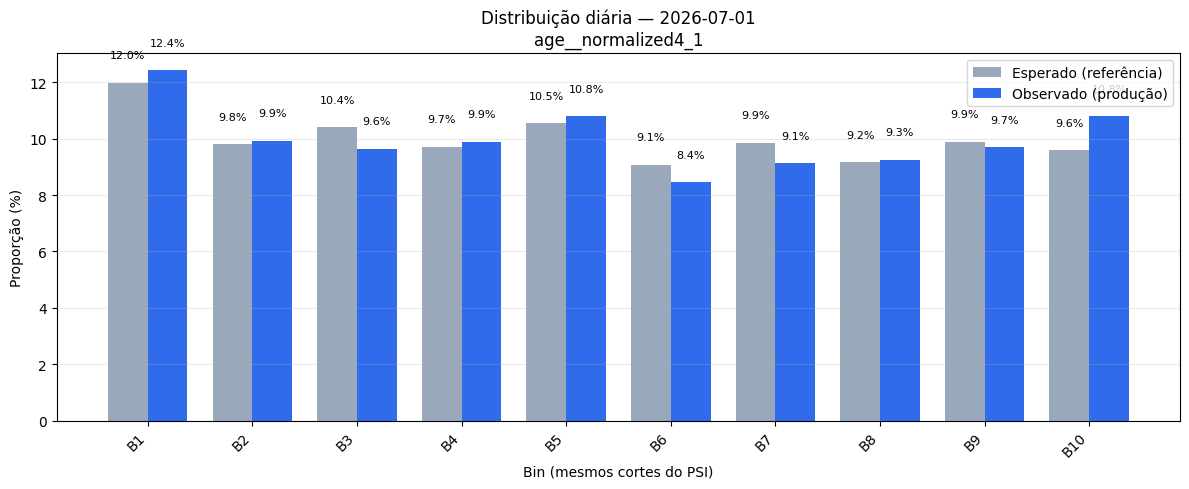

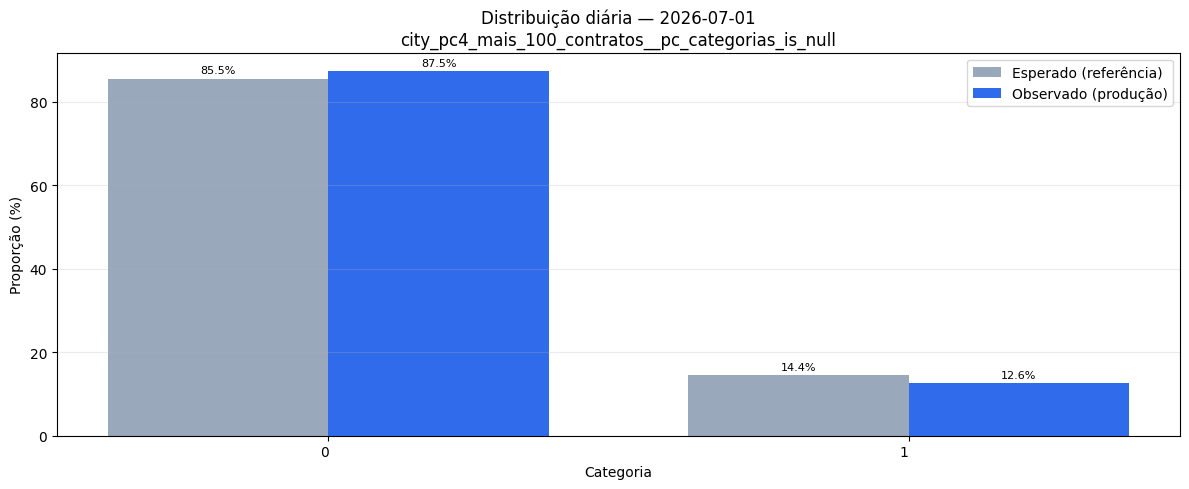

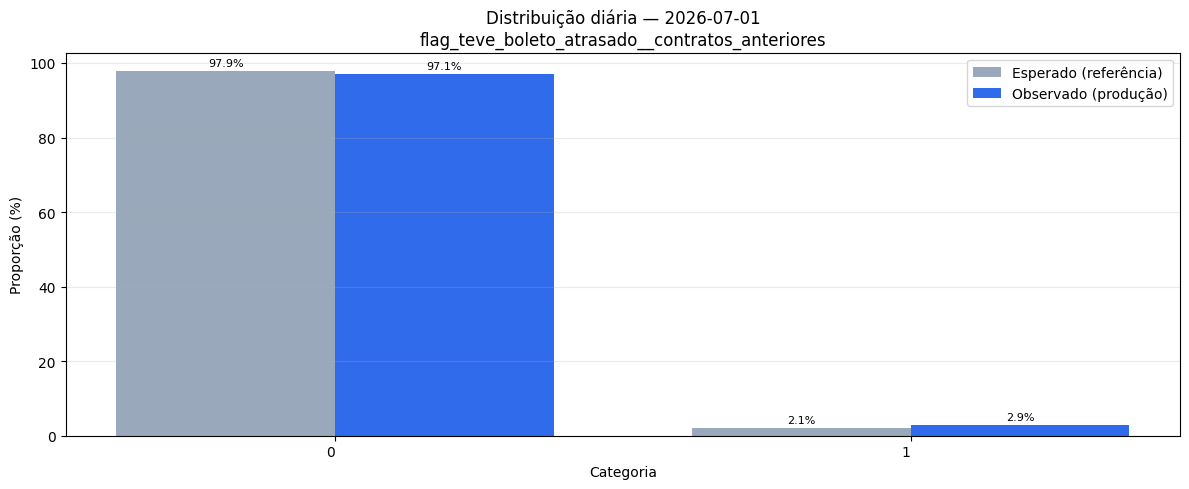

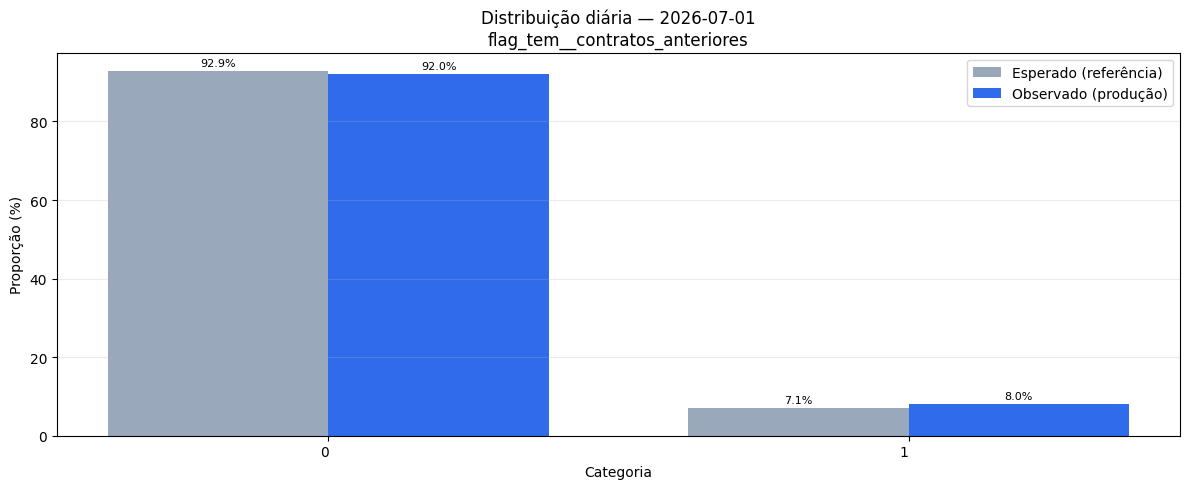

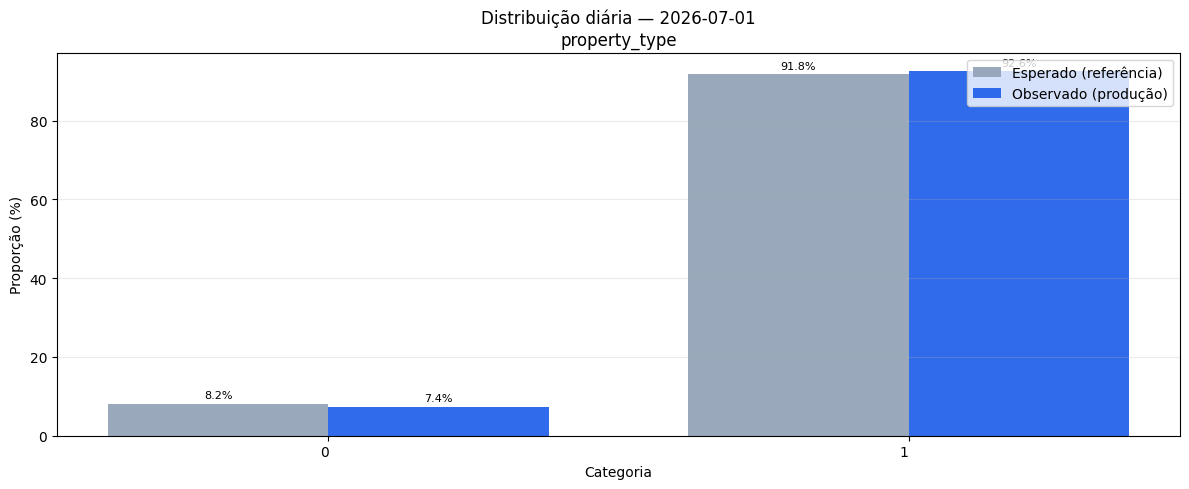

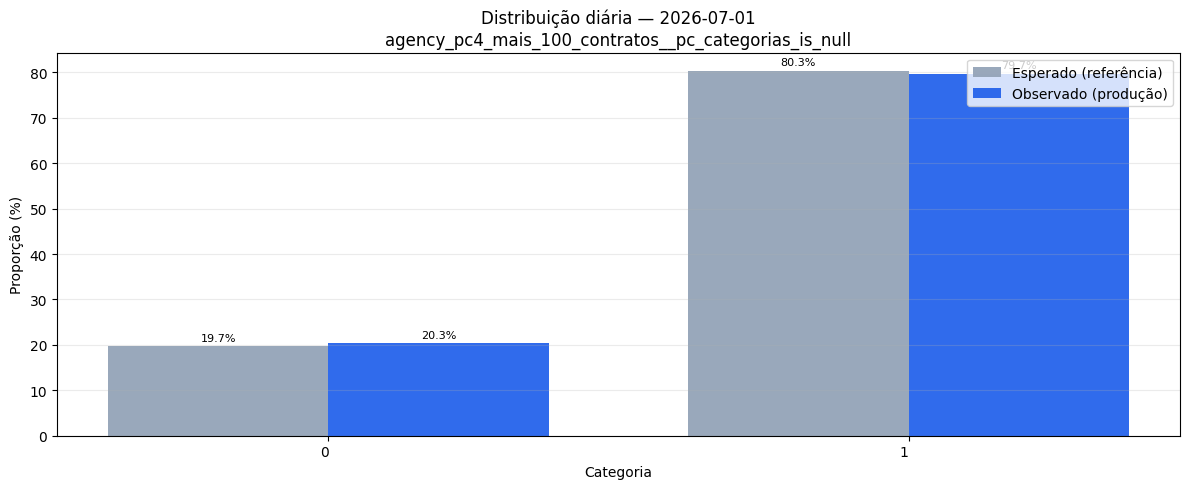

In [47]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_day,
    artifact=psi_reference_artifact,
    variables=model_vars,
    top_n=12,
    title_prefix=f"Distribuição diária — {target_day}",
)

## PSI Semanal W-1 (Última Semana Completa)

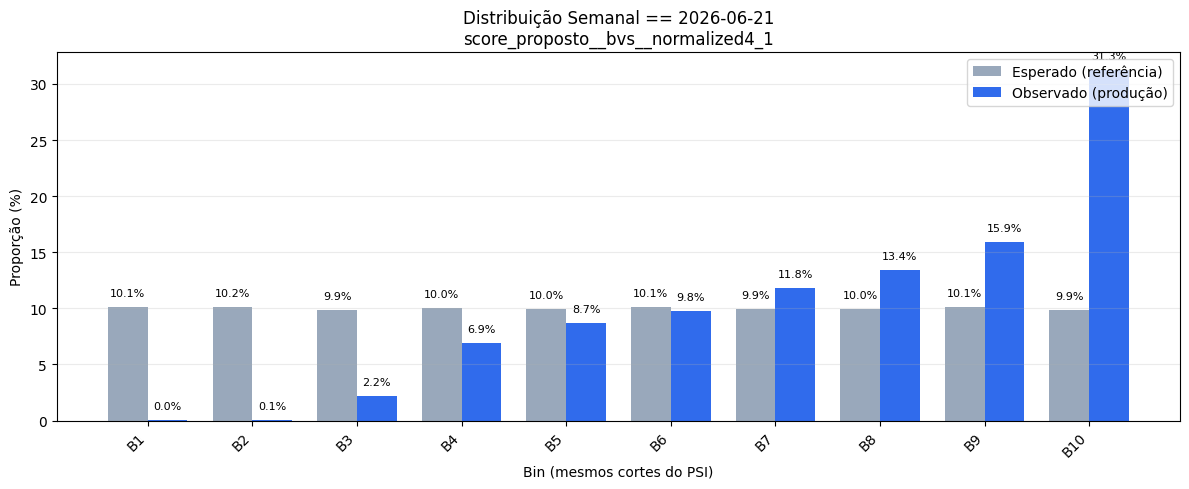

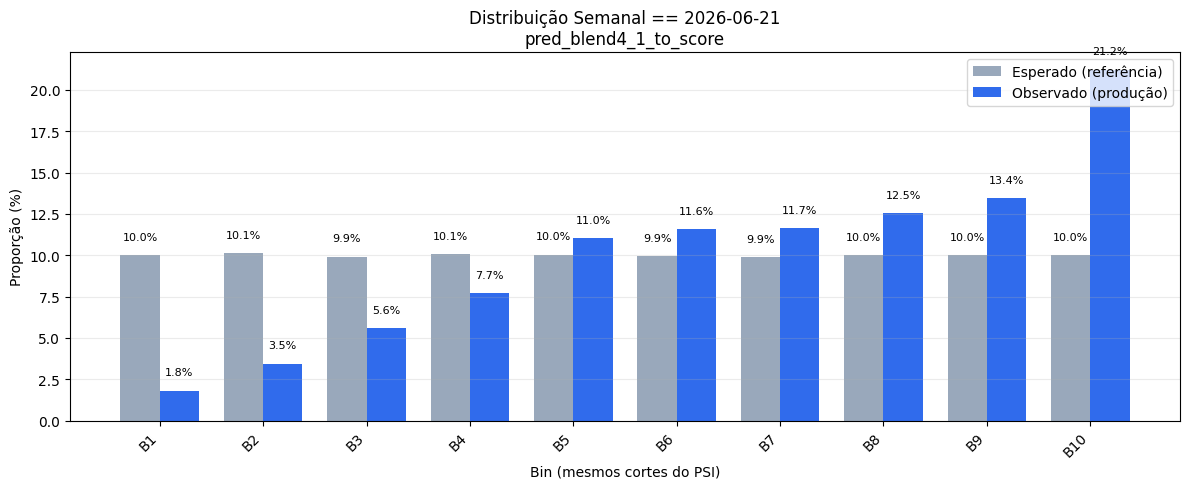

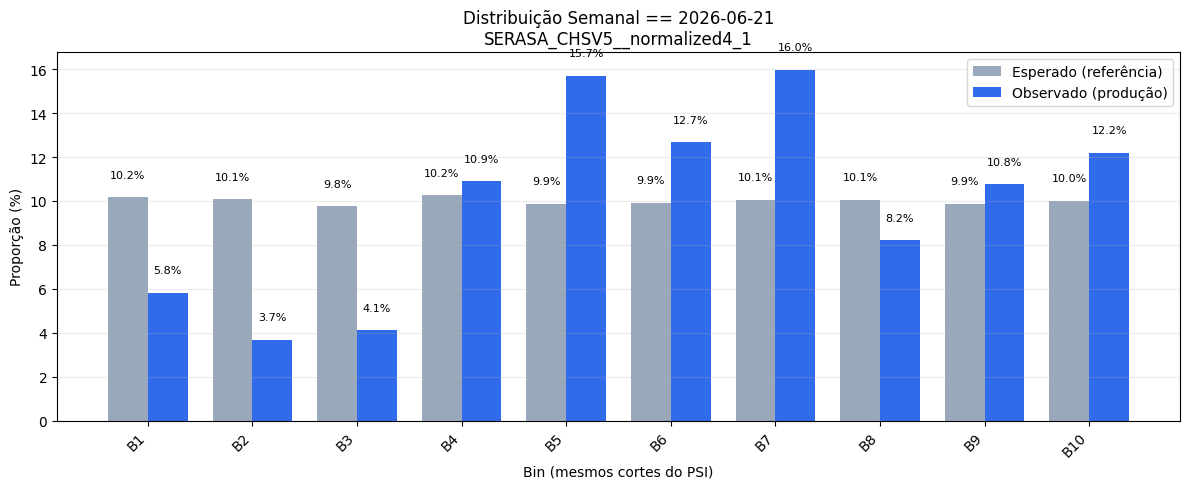

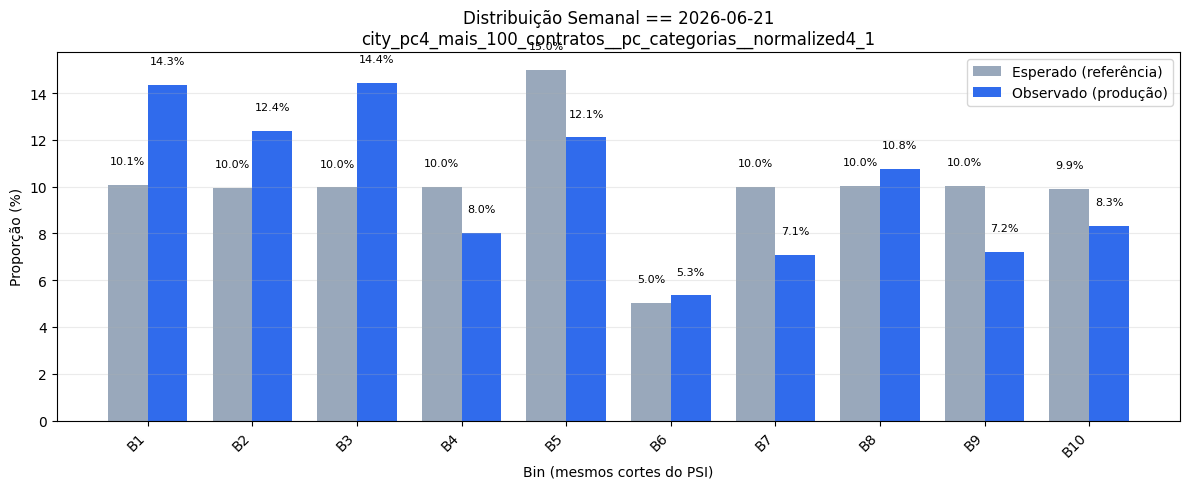

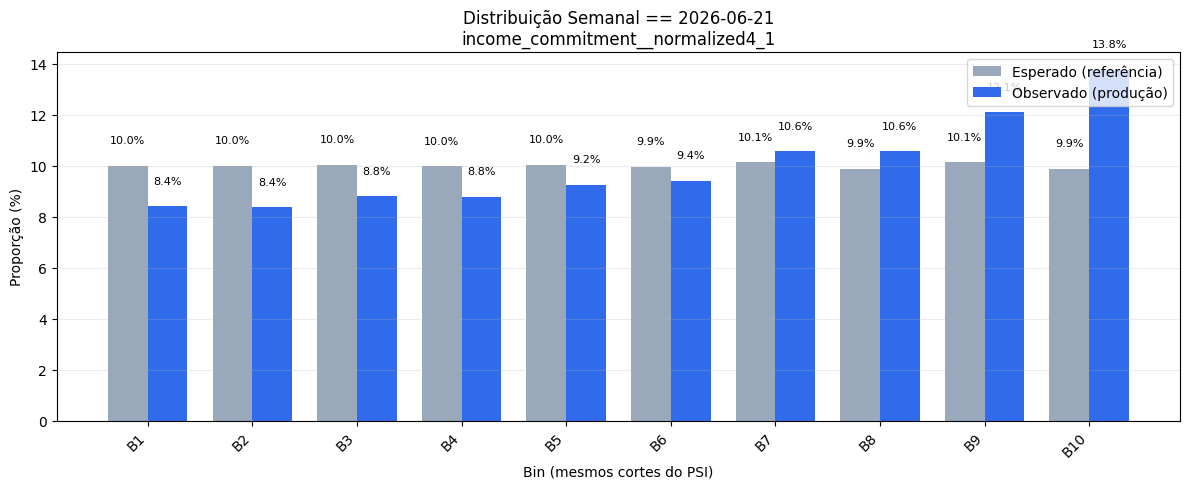

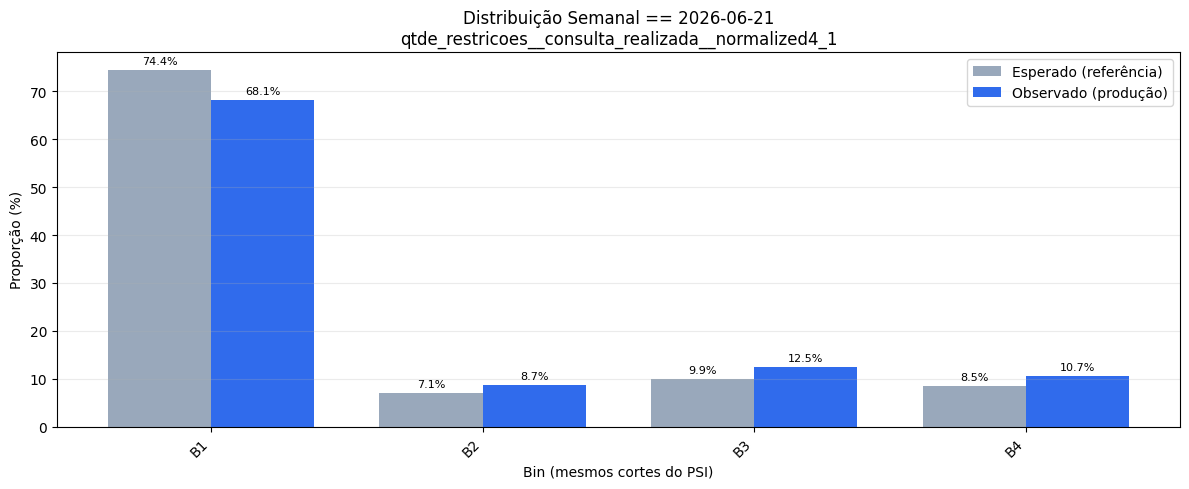

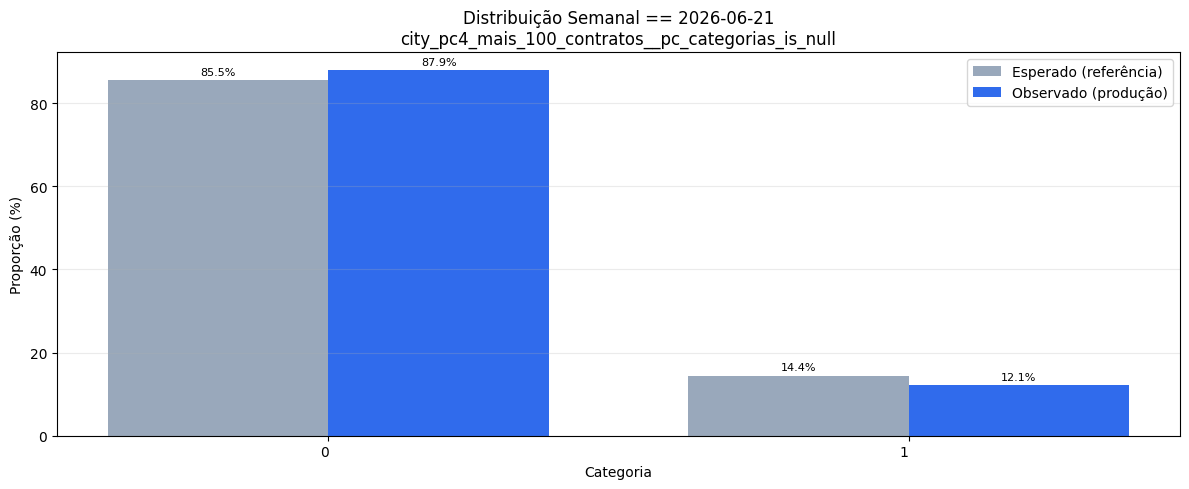

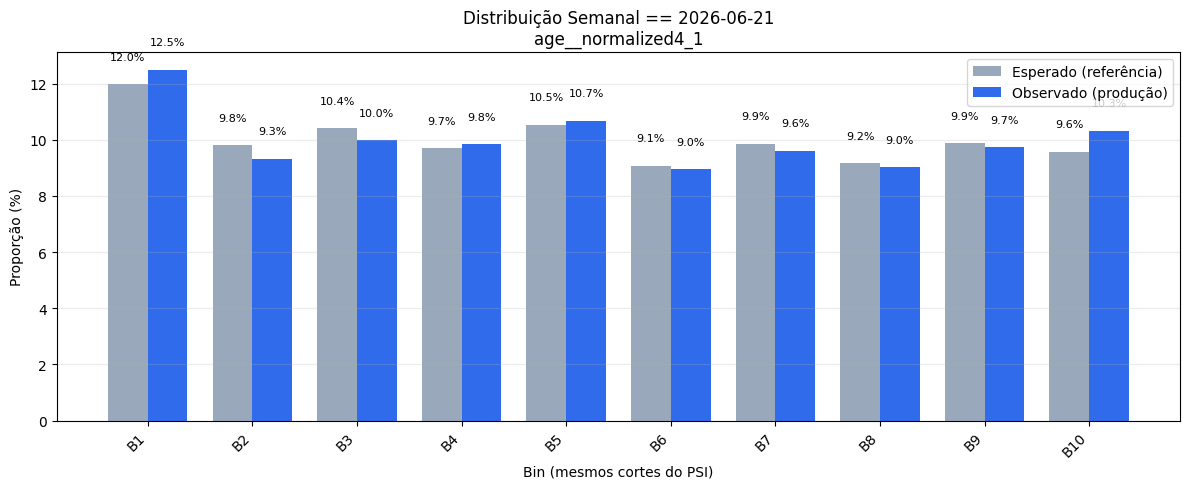

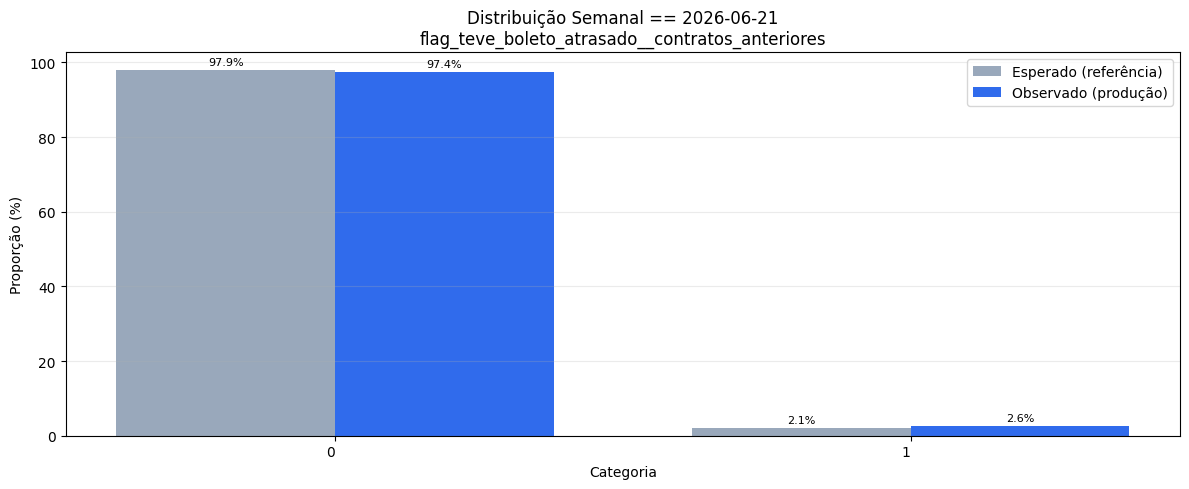

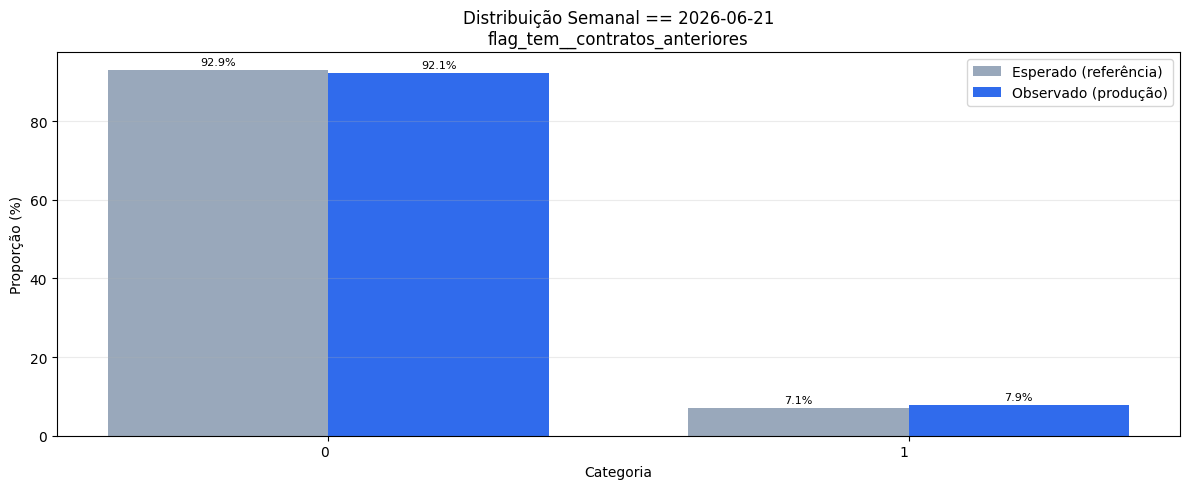

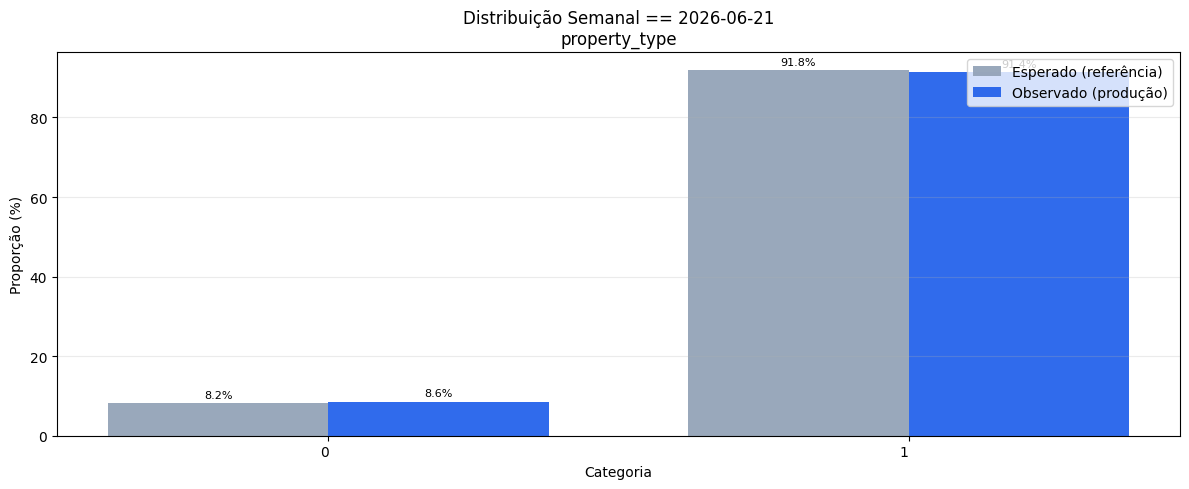

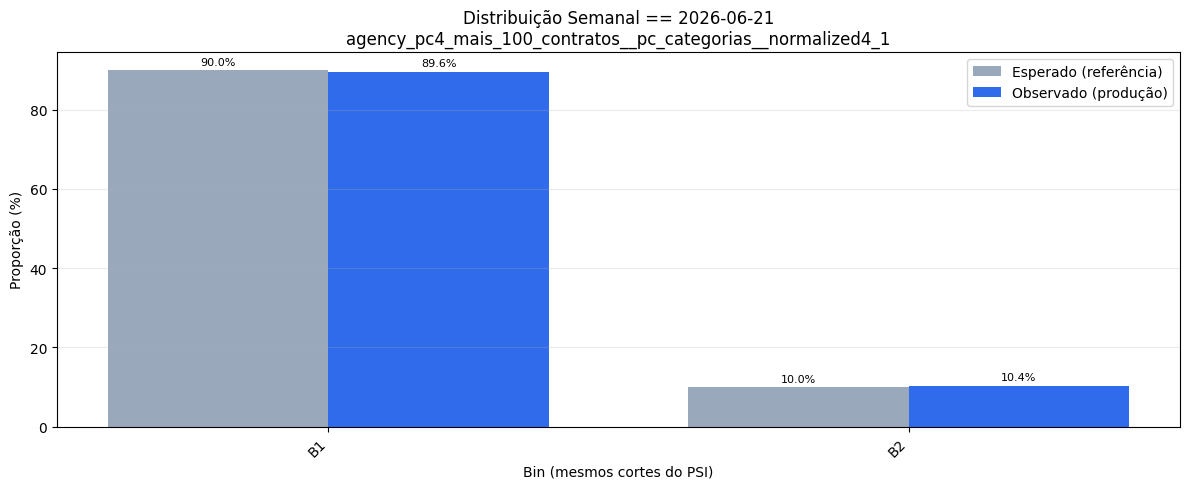

In [48]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_week,
    artifact=psi_reference_artifact,
    variables=model_vars,
    top_n=12,
    title_prefix=f"Distribuição Semanal == {target_week}",
)

# Falhas - Uniproponente

Garantir que não estamos comprando SERASA para esse público

10-11% do público OOT passa direto por BVS (Blend4).
15-17% é Rating E pelo Score BVS.

In [49]:
REGRA_ORDER = ["BLEND4", "E_BVS"]
REGRA_COLOR_MAP = {
    "BLEND4": "#3B82F6",
    "E_BVS": "#F59E0B",
}

df_monitor = filter_monitoring_week_window(df_uniprop, n_weeks=6, mode="rolling")

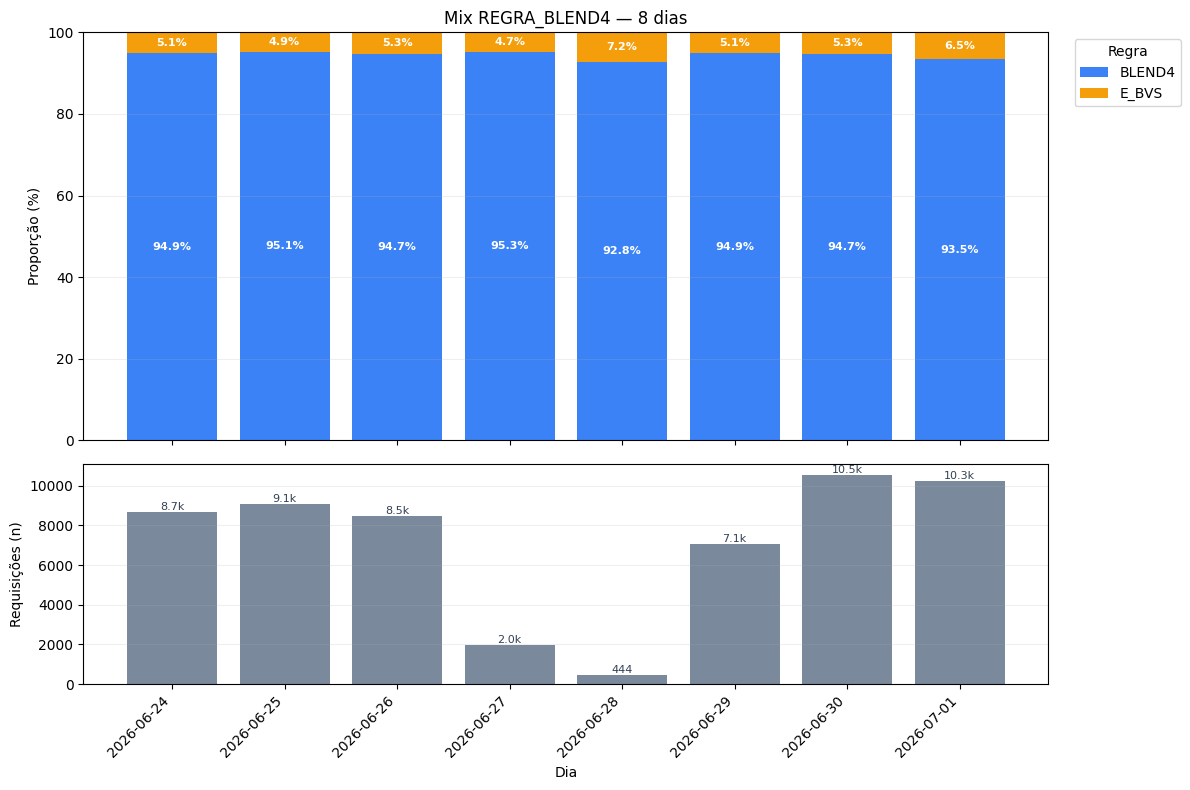

In [50]:
# Diário (mesma base, janela diária)
df_daily = filter_monitoring_window(df_monitor, n_days=8, mode="rolling")
plot_daily_mix(
    df_daily,
    category_col="REGRA_BLEND_4",
    title=f"Mix REGRA_BLEND4 — 8 dias",
    category_order=REGRA_ORDER,
    color_map=REGRA_COLOR_MAP,
    legend_title="Regra",
    min_label_pct=3.0,
)

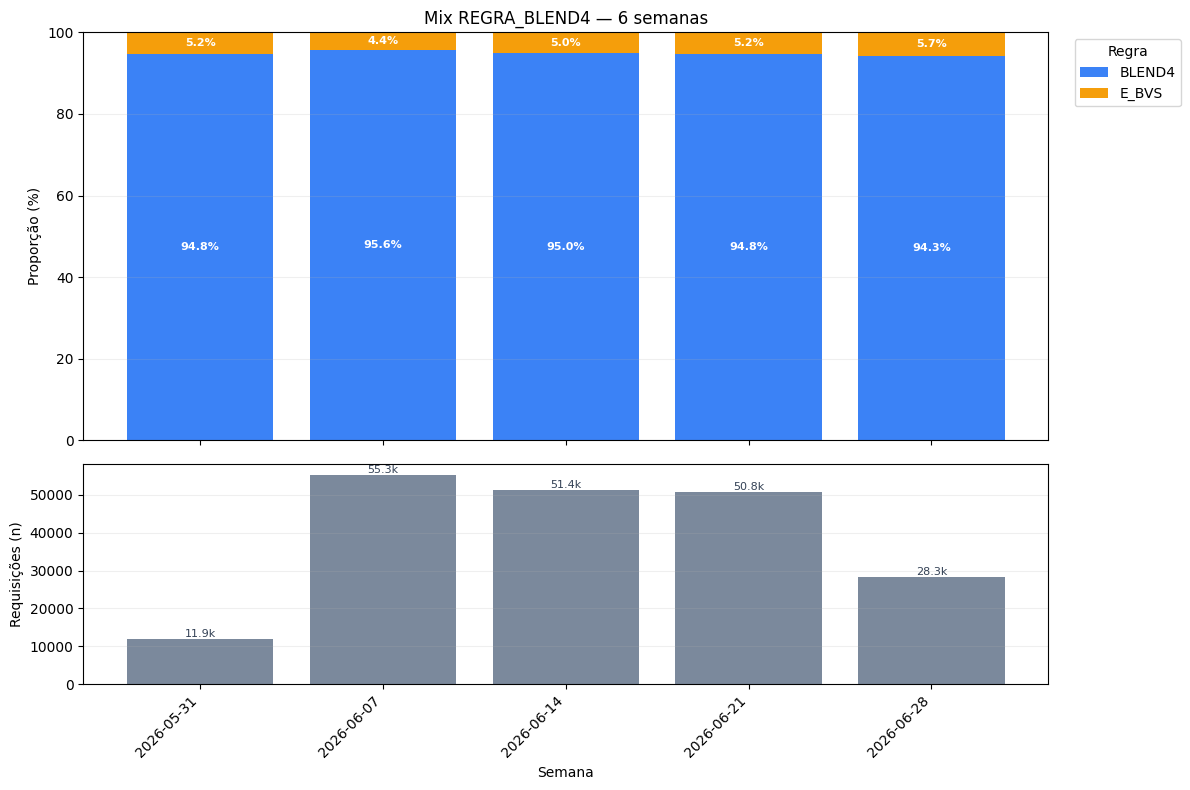

In [51]:
# Semanal
plot_weekly_mix(
    df_monitor,
    category_col="REGRA_BLEND_4",
    title="Mix REGRA_BLEND4 — 6 semanas",
    category_order=REGRA_ORDER,
    color_map=REGRA_COLOR_MAP,
    legend_title="Regra",
    min_label_pct=3.0,
)

In [52]:
df_bvs_mon = df_monitor[df_monitor["REGRA_BLEND_4"] == "E_BVS"].copy()

df_bvs_mon["status_serasa"] = np.where(
    df_bvs_mon["SCORE_SERASA"].isna(),  #Estou considerando que o score serasa é nulo quando não tem SERASA (Valores especiais?)
    "Conforme (sem SERASA)",
    "Violação (com SERASA)",
)

SERASA_STATUS_ORDER = ["Conforme (sem SERASA)", "Violação (com SERASA)"]
SERASA_STATUS_COLORS = {
    "Conforme (sem SERASA)": "#22C55E",
    "Violação (com SERASA)": "#EF4444",
}

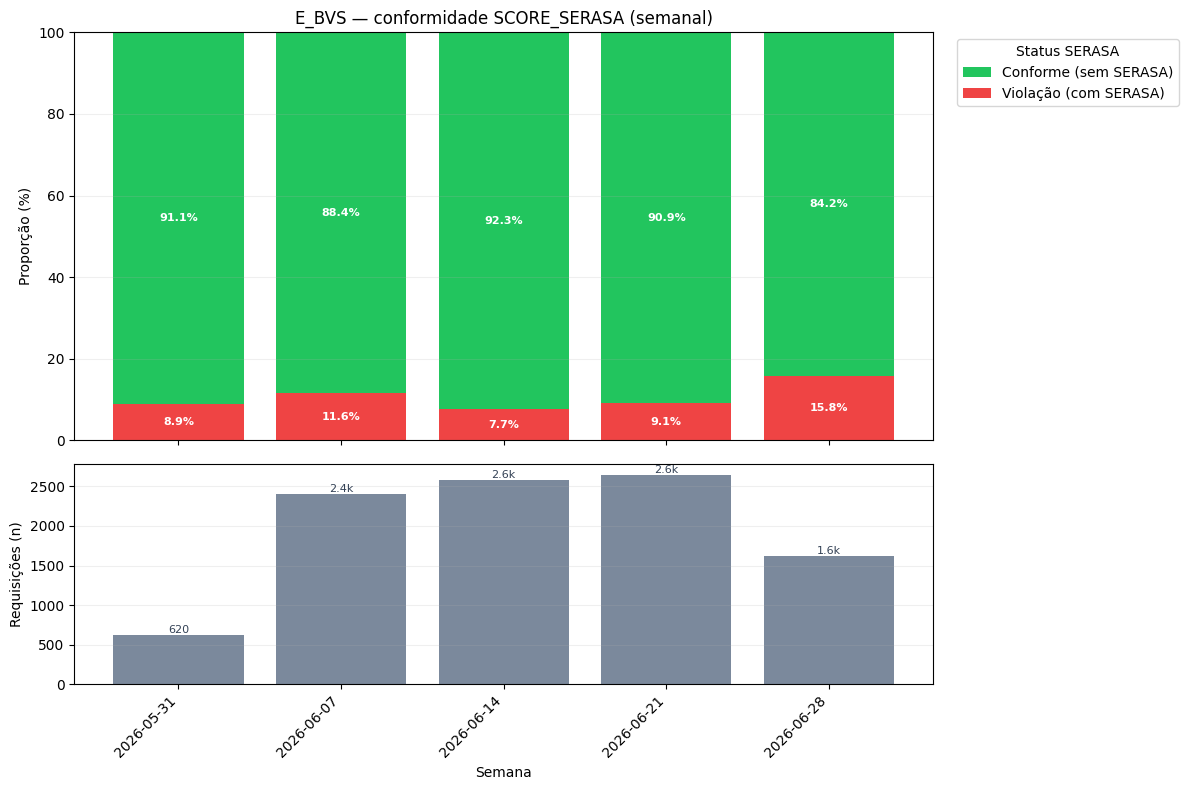

In [53]:
plot_weekly_mix(
    df_bvs_mon,
    category_col="status_serasa",
    title="E_BVS — conformidade SCORE_SERASA (semanal)",
    category_order=SERASA_STATUS_ORDER,
    color_map=SERASA_STATUS_COLORS,
    legend_title="Status SERASA",
    reverse_stack=True,  # violação no topo, mais visível
    min_label_pct=1.0,
)

In [54]:
df_E_BVS_mon = df_monitor[df_monitor["REGRA_BLEND_4"] == "E_BVS"].copy()

score_bvs = pd.to_numeric(df_E_BVS_mon["SCORE_BVS"], errors="coerce")

df_E_BVS_mon["status_bvs"] = np.select(
    [
        score_bvs.isna(),
        (score_bvs >= 0) & (score_bvs <= 334),
        (score_bvs < 0) | (score_bvs > 334),
    ],
    [
        "Violação (NaN)",
        "Conforme (0-334)",
        "Violação (fora da faixa)",
    ],
    default="Violação (NaN)",
)

BLEND4_STATUS_ORDER = [
    "Conforme (0-334)",
    "Violação (NaN)",
    "Violação (fora da faixa)",
]
BLEND4_STATUS_COLORS = {
    "Conforme (0-334)": "#22C55E",
    "Violação (NaN)": "#EF4444",
    "Violação (fora da faixa)": "#F97316",
}

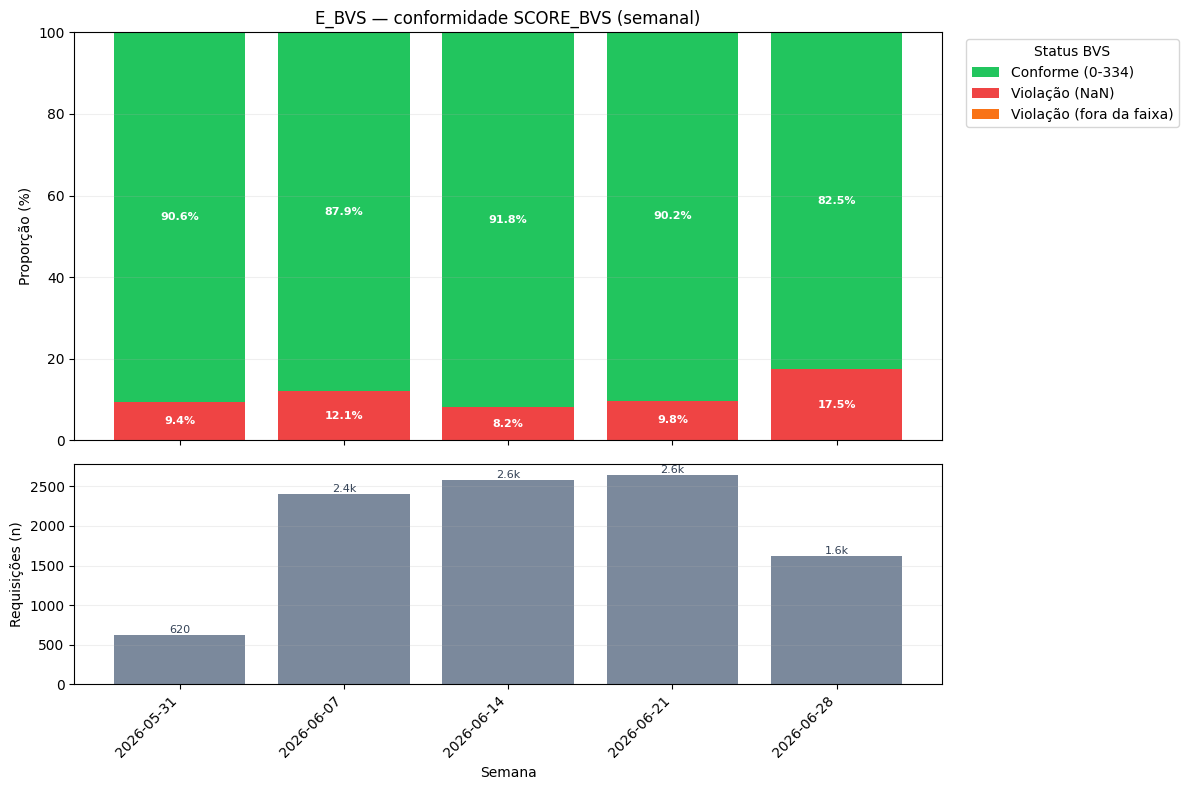

In [55]:
plot_weekly_mix(
    df_E_BVS_mon,
    category_col="status_bvs",
    title="E_BVS — conformidade SCORE_BVS (semanal)",
    category_order=BLEND4_STATUS_ORDER,
    color_map=BLEND4_STATUS_COLORS,
    legend_title="Status BVS",
    reverse_stack=True,
    min_label_pct=1.0,
)

In [56]:
df_blend4_mon = df_monitor[df_monitor["REGRA_BLEND_4"] == "BLEND4"].copy()

# Opcional: alinhar com filtros do notebook
# df_blend4_mon = df_blend4_mon[
#     (df_blend4_mon["income"] > 0) & (df_blend4_mon["qtd_proponentes"] == 1)
# ]

score_serasa = pd.to_numeric(df_blend4_mon["SCORE_SERASA"], errors="coerce")
score_bvs = pd.to_numeric(df_blend4_mon["SCORE_BVS"], errors="coerce")

df_blend4_mon["status_serasa"] = np.select(
    [
        score_serasa.isna(),
        (score_serasa >= 0) & (score_serasa <= 1000),
        (score_serasa < 0) | (score_serasa > 1000),
    ],
    [
        "Violação (NaN)",
        "Conforme (0–1000)",
        "Violação (fora da faixa)",
    ],
    default="Violação (NaN)",
)

df_blend4_mon["status_bvs"] = np.select(
    [
        score_bvs.isna(),
        (score_bvs >= 0) & (score_bvs <= 1000),
        (score_bvs < 0) | (score_bvs > 1000),
    ],
    [
        "Violação (NaN)",
        "Conforme (0–1000)",
        "Violação (fora da faixa)",
    ],
    default="Violação (NaN)",
)

BLEND4_STATUS_ORDER = [
    "Conforme (0–1000)",
    "Violação (NaN)",
    "Violação (fora da faixa)",
]
BLEND4_STATUS_COLORS = {
    "Conforme (0–1000)": "#22C55E",
    "Violação (NaN)": "#EF4444",
    "Violação (fora da faixa)": "#F97316",
}

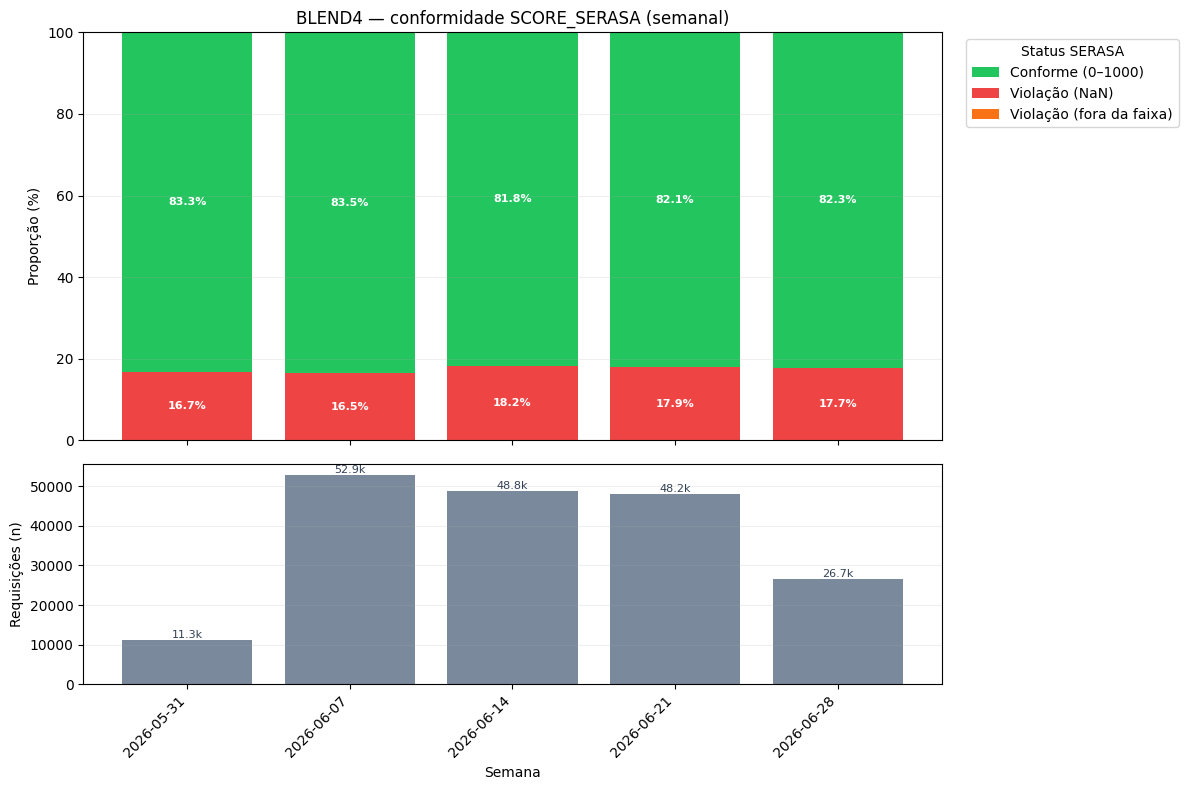

In [57]:
plot_weekly_mix(
    df_blend4_mon,
    category_col="status_serasa",
    title="BLEND4 — conformidade SCORE_SERASA (semanal)",
    category_order=BLEND4_STATUS_ORDER,
    color_map=BLEND4_STATUS_COLORS,
    legend_title="Status SERASA",
    reverse_stack=True,
    min_label_pct=1.0,
)

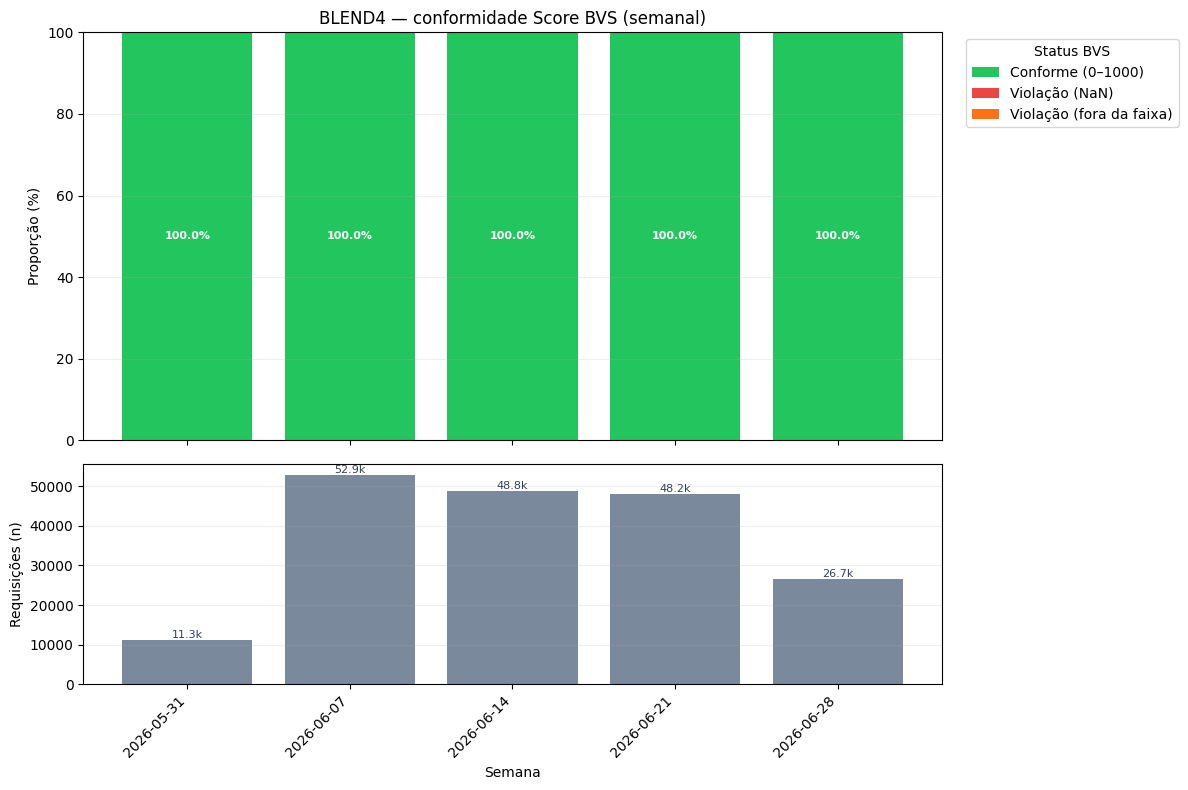

In [58]:
plot_weekly_mix(
    df_blend4_mon,
    category_col="status_bvs",
    title="BLEND4 — conformidade Score BVS (semanal)",
    category_order=BLEND4_STATUS_ORDER,
    color_map=BLEND4_STATUS_COLORS,
    legend_title="Status BVS",
    reverse_stack=True,
    min_label_pct=1.0,
)

# PSI Base Geral Uniproponente

## Dia e Semana Raw

In [59]:
WINDOW_DAYS = 8

df_daily = filter_monitoring_window(
    df_uniprop,
    n_days=WINDOW_DAYS,
    mode="rolling",
)
print(f"Período: {df_daily['requested_at'].min()} → {df_daily['requested_at'].max()}")
print(f"Volume total: {len(df_daily):,}")

Período: 2026-06-24 00:00:00 → 2026-07-01 00:00:00
Volume total: 56,492


In [60]:
WINDOW_WEEKS = 6

df_weekly = filter_monitoring_week_window(
    df_uniprop,
    n_weeks=WINDOW_WEEKS,
    mode="rolling",
)
print(f"Semanas: {df_weekly['year_week'].nunique()} | Volume: {len(df_weekly):,}")
print(f"Período: {df_weekly['requested_at'].min()} → {df_weekly['requested_at'].max()}")

Semanas: 5 | Volume: 197,658
Período: 2026-06-04 00:00:00 → 2026-07-01 00:00:00


In [61]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "blend4_bvs_score_psi_reference.pkl"
psi_reference_artifact_bvs = load_psi_reference(PSI_REFERENCE_PATH)

In [62]:
PSI_REFERENCE_PATH = ANALYTICS_DIR / "psi_income_rental_reference.pkl"
psi_reference_artifact_raw = load_psi_reference(PSI_REFERENCE_PATH)

In [63]:
daily_blend4 = df_daily[df_daily["message_decisao"] == "BLEND4"].copy()
weekly_blend4 = df_weekly[df_weekly["message_decisao"] == "BLEND4"].copy()

psi_daily_bvs = monitor_daily_psi(
    df_production=daily_blend4,
    artifact=psi_reference_artifact_bvs,
    date_col="requested_at",
    baseline_ref=psi_baseline_ref,
    variables=["SCORE_BVS"],
)

psi_weekly_bvs = monitor_weekly_psi(
    df_production=weekly_blend4,
    artifact=psi_reference_artifact_bvs,
    baseline_ref=psi_baseline_ref,
    variables=["SCORE_BVS"],
)

psi_daily_income_rental = monitor_daily_psi(
    df_production=daily_blend4,
    artifact=psi_reference_artifact_raw,
    date_col="requested_at",
    baseline_ref=psi_baseline_ref,
    variables=["income", "rental_value"],
)

psi_weekly_income_rental = monitor_weekly_psi(
    df_production=weekly_blend4,
    artifact=psi_reference_artifact_raw,
    baseline_ref=psi_baseline_ref,
    variables=["income", "rental_value"],
)

In [64]:
target_day = pd.to_datetime(daily_blend4["requested_at"]).max().strftime("%Y-%m-%d")
print(f"Target day: {target_day}")
df_day = daily_blend4[
    pd.to_datetime(daily_blend4["requested_at"]).dt.strftime("%Y-%m-%d") == target_day
]

Target day: 2026-07-01


In [65]:
target_week = target_week = week_order[-2]
print(f"Target Week == {target_week} (Última Semana Completa)")
df_week = weekly_blend4[
    weekly_blend4["year_week"] == target_week]

Target Week == 2026-06-21 (Última Semana Completa)


In [66]:
# psi_daily
# POR QUE TEM NAN

## PSI RAW BVS

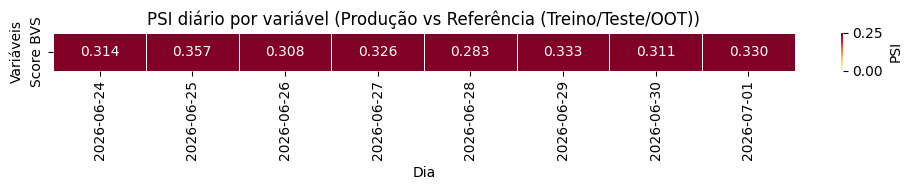

In [67]:
pivot = (
    psi_daily_bvs
    .pivot(index="variable", columns="monitoring_day", values="psi")
    .reindex(["SCORE_BVS"])
    .rename(index={"SCORE_BVS": "Score BVS"})
)
fig, ax = plt.subplots(figsize=(10, 2))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI diário por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Dia")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

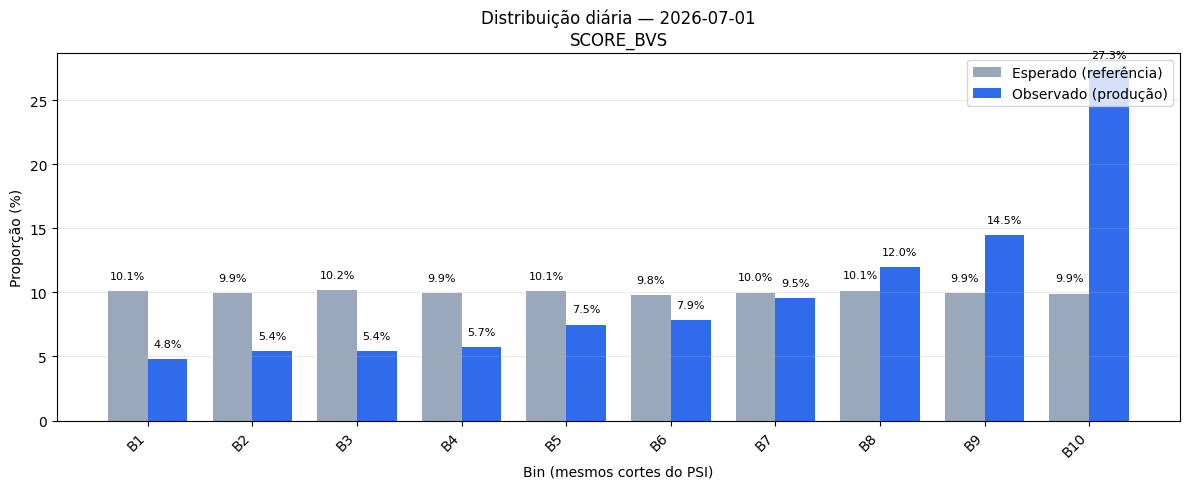

In [68]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_day,
    artifact=psi_reference_artifact_bvs,
    variables=["SCORE_BVS"],
    title_prefix=f"Distribuição diária — {target_day}",
)

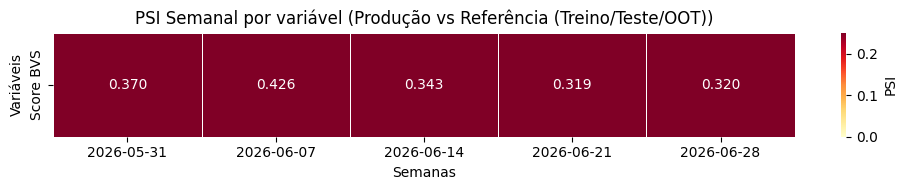

In [69]:
pivot = (
    psi_weekly_bvs
    .pivot(index="variable", columns="monitoring_week", values="psi")
    .reindex(["SCORE_BVS"])
    .rename(index={"SCORE_BVS": "Score BVS"})
)
fig, ax = plt.subplots(figsize=(10, 2))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI Semanal por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Semanas")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

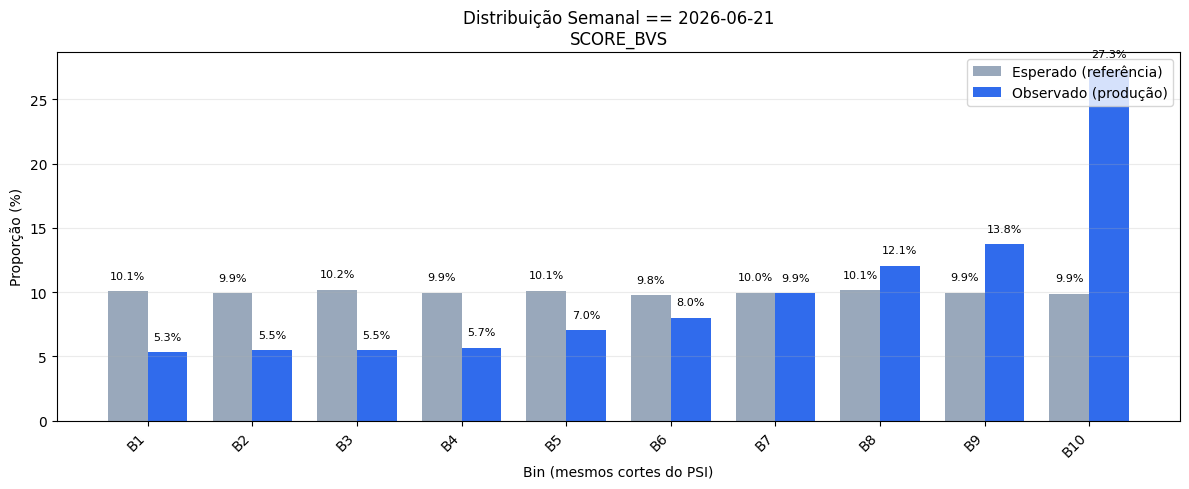

In [70]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_week,
    artifact=psi_reference_artifact_bvs,
    variables=["SCORE_BVS"],
    title_prefix=f"Distribuição Semanal == {target_week}",
)

## PSI RAW Renda e Aluguel

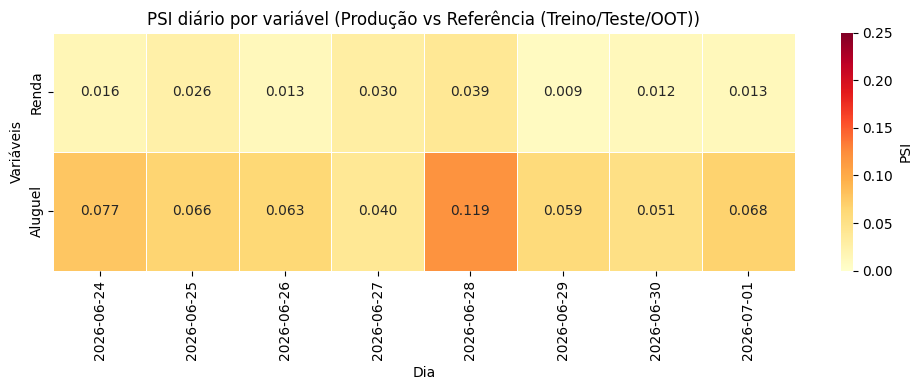

In [71]:
pivot = (
    psi_daily_income_rental
    .pivot(index="variable", columns="monitoring_day", values="psi")
    .reindex(["income", "rental_value"])
    .rename(index={"income": "Renda", "rental_value": "Aluguel"})
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI diário por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Dia")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

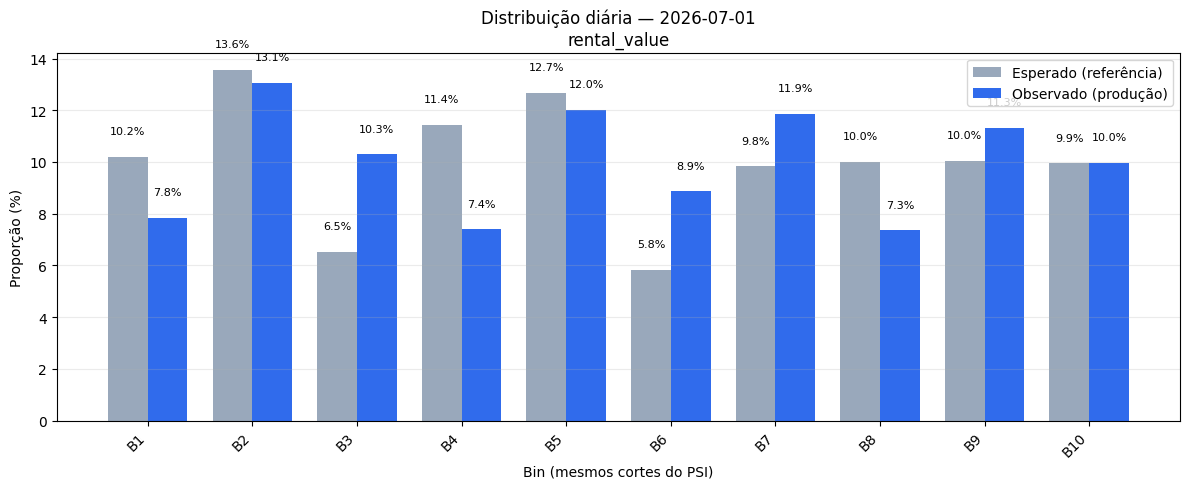

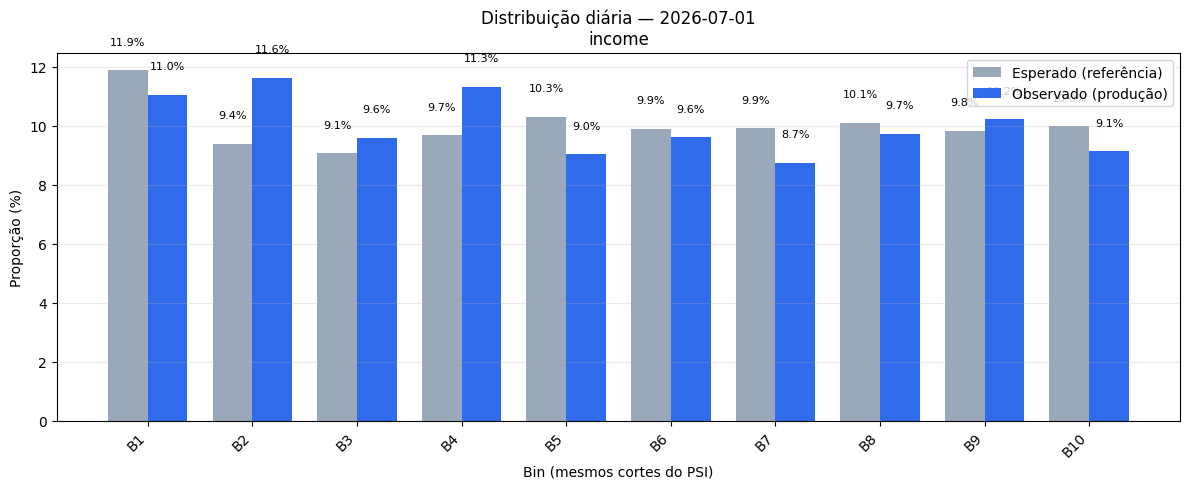

In [72]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_day,
    artifact=psi_reference_artifact_raw,
    variables=["income", "rental_value"],
    title_prefix=f"Distribuição diária — {target_day}",
)

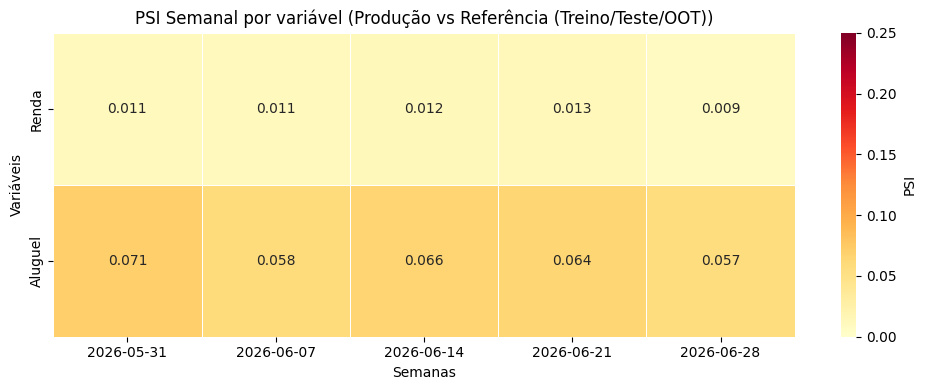

In [73]:
pivot = (
    psi_weekly_income_rental
    .pivot(index="variable", columns="monitoring_week", values="psi")
    .reindex(["income", "rental_value"])
    .rename(index={"income": "Renda", "rental_value": "Aluguel"})
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    cbar_kws={"label": "PSI"},
    ax=ax,
)
ax.set_title("PSI Semanal por variável (Produção vs Referência (Treino/Teste/OOT))")
ax.set_xlabel("Semanas")
ax.set_ylabel("Variáveis")
plt.tight_layout()
plt.show()

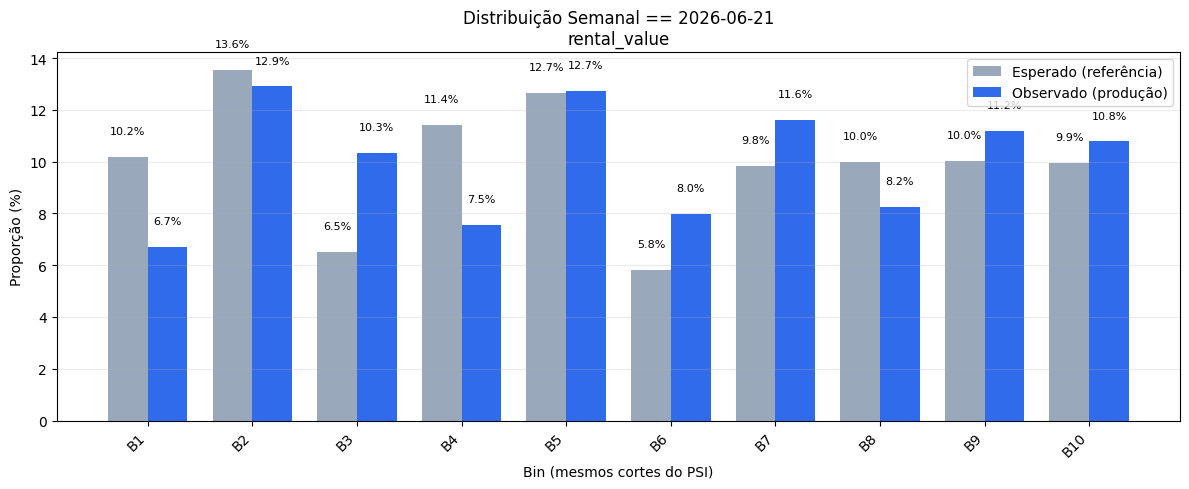

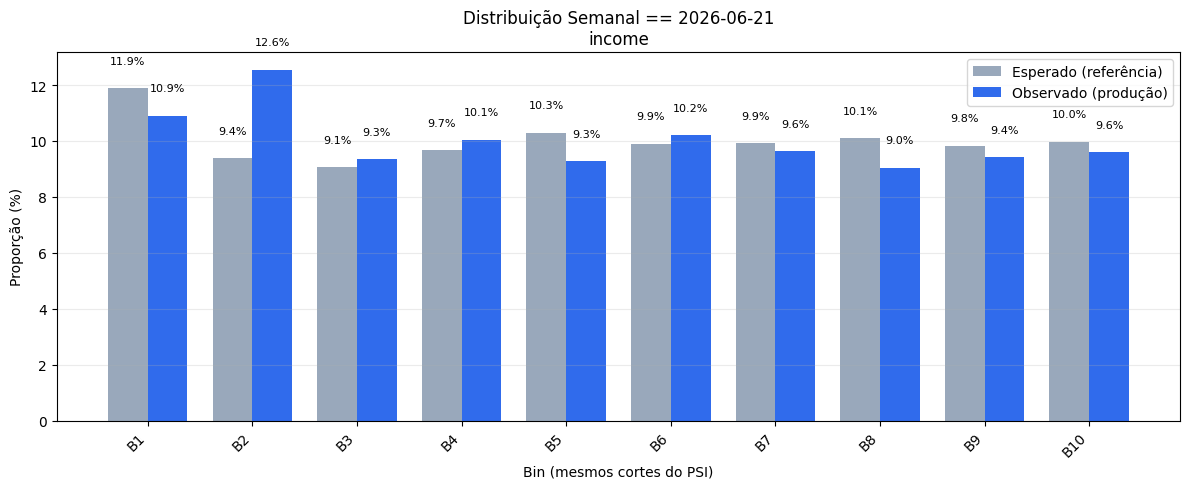

In [74]:
dist_tables = plot_top_psi_distributions(
    df_actual=df_week,
    artifact=psi_reference_artifact_raw,
    variables=["income", "rental_value"],
    title_prefix=f"Distribuição Semanal == {target_week}",
)

In [75]:
from build_report_html import export_notebook_report

report_path = export_notebook_report(
    "02.Monitoramento_Blend4.ipynb",
    title="Monitoramento Blend4",
)
print(f"Report generated: {report_path}")

[NbConvertApp] Converting notebook /Users/lucas.nascimento/Monitoramento_Modelos/02.Monitoramento_Blend4.ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('execution_count', 'outputs' were unexpected)

Failed validating 'additionalProperties' in markdown_cell:

On instance['cells'][67]:
{'cell_type': 'markdown',
 'execution_count': None,
 'id': 'af9d4ecc',
 'metadata': {},
 'outputs': ['...0 outputs...'],
 'source': '## PSI Semanal — Semana Anterior Completa\n'}


Report generated: /Users/lucas.nascimento/Monitoramento_Modelos/02.Monitoramento_Blend4_report.html


[NbConvertApp] WARNING | Alternative text is missing on 56 image(s).
[NbConvertApp] Writing 3497176 bytes to /Users/lucas.nascimento/Monitoramento_Modelos/02.Monitoramento_Blend4.html
